In [1]:
# Cell 0 | 设置虚拟IL候选库生成与冻结LightGBM黏度预测环境

import hashlib
import itertools
import json
import math
import os
import random
import sys
import warnings
from datetime import datetime
from pathlib import Path
from typing import Union

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Image, display
from rdkit import Chem, RDLogger
from rdkit.Chem import rdchem
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import NNConv, global_mean_pool

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.error")
RDLogger.DisableLog("rdApp.warning")


def find_project_root(start_path: Union[str, Path] = ".") -> Path:
    current = Path(start_path).resolve()

    for candidate in [current] + list(current.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "未找到项目根目录。请确认当前Notebook位于：\n"
        r"D:\jupyter\IL_ML_Project\notebooks"
    )


def sha256_file(
    path: Union[str, Path],
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(chunk_size),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def array_sha256(array: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(
        np.asarray(array)
    )

    return hashlib.sha256(
        contiguous.tobytes()
    ).hexdigest()


def read_json(
    path: Union[str, Path],
) -> dict:
    with Path(path).open(
        "r",
        encoding="utf-8",
    ) as file:
        return json.load(file)


def to_jsonable(value):
    if isinstance(value, dict):
        return {
            str(key): to_jsonable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            to_jsonable(item)
            for item in value
        ]

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    return value


def save_json_atomic(
    data: dict,
    output_path: Union[str, Path],
) -> None:
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            to_jsonable(data),
            file,
            ensure_ascii=False,
            indent=2,
        )

    os.replace(
        temporary_path,
        output_path,
    )


def save_csv_atomic(
    dataframe: pd.DataFrame,
    output_path: Union[str, Path],
) -> None:
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
        encoding="utf-8-sig",
    )

    os.replace(
        temporary_path,
        output_path,
    )


def save_npy_atomic(
    array: np.ndarray,
    output_path: Union[str, Path],
) -> None:
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    with temporary_path.open("wb") as file:
        np.save(
            file,
            np.asarray(array),
            allow_pickle=False,
        )

    os.replace(
        temporary_path,
        output_path,
    )


def save_torch_atomic(
    obj,
    output_path: Union[str, Path],
) -> None:
    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    torch.save(
        obj,
        temporary_path,
    )

    os.replace(
        temporary_path,
        output_path,
    )


def seed_everything(
    seed: int = 42,
) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


ROOT = find_project_root(
    Path.cwd()
)

EXPERIMENT_ROOT = (
    ROOT
    / "small_paper_data"
    / "viscosity_10point_holdout"
)

ML_READY_PATH = (
    EXPERIMENT_ROOT
    / "ml_ready"
    / "ml_ready_A.csv"
)

MPNN_MODEL_DIR = (
    EXPERIMENT_ROOT
    / "models"
    / "mpnn_feature_extractors"
)

MPNN_MODEL_PATH = (
    MPNN_MODEL_DIR
    / "mpnn_feature_extractor_viscosity.pt"
)

TP_SCALER_PATH = (
    MPNN_MODEL_DIR
    / "tp_scaler_viscosity.joblib"
)

MPNN_METADATA_PATH = (
    MPNN_MODEL_DIR
    / "mpnn_feature_extractor_viscosity_metadata.json"
)

PIPELINE_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "model_training_3models_cv_no_leakage_2splits"
)

FINAL_FREEZE_ROOT = (
    PIPELINE_ROOT
    / "final_two_model_freeze"
)

FINAL_LGBM_PATH = (
    FINAL_FREEZE_ROOT
    / "models"
    / "final_LightGBM_viscosity.joblib"
)

FINAL_SCALER_PATH = (
    FINAL_FREEZE_ROOT
    / "scalers"
    / "final_downstream_feature_scaler.joblib"
)

FINAL_PARAMETER_PATH = (
    FINAL_FREEZE_ROOT
    / "parameters"
    / "final_parameters_LightGBM.json"
)

FINAL_FREEZE_MANIFEST_PATH = (
    FINAL_FREEZE_ROOT
    / "logs"
    / "final_two_model_freeze_manifest.json"
)

LOCKED10_FINAL_MANIFEST_PATH = (
    EXPERIMENT_ROOT
    / "outputs"
    / "external_holdout_10point_LGBM_Transformer_final"
    / "logs"
    / "locked10_LGBM_Transformer_validation_manifest.json"
)

OUT_DIR = (
    EXPERIMENT_ROOT
    / "outputs"
    / "virtual_IL_lightgbm_viscosity"
)

TABLE_DIR = OUT_DIR / "tables"
FEATURE_DIR = OUT_DIR / "features"
LOG_DIR = OUT_DIR / "logs"

FIG_DIR = OUT_DIR / "figures"
PNG_DIR = FIG_DIR / "PNG"
SVG_DIR = FIG_DIR / "SVG"
PDF_DIR = FIG_DIR / "PDF"
CSV_DIR = FIG_DIR / "CSV"

for directory in [
    OUT_DIR,
    TABLE_DIR,
    FEATURE_DIR,
    LOG_DIR,
    FIG_DIR,
    PNG_DIR,
    SVG_DIR,
    PDF_DIR,
    CSV_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

out_dir_text = str(
    OUT_DIR.resolve()
).lower()

if (
    "small_paper_data" not in out_dir_text
    or "viscosity_10point_holdout"
    not in out_dir_text
):
    raise RuntimeError(
        "虚拟IL输出目录异常，已停止运行。"
    )

TARGET_T = 298.15
TARGET_P = 1.01325

EXCLUDE_EXISTING_PAIRS = True
MAX_VIRTUAL_CANDIDATES = 20000
RANDOM_SEED = 42

EXPECTED_DEVELOPMENT_ROWS = 16216
EXPECTED_FEATURE_DIM = 130

RUN_CODE_VERSION = (
    "19_virtual_IL_frozen_"
    "LGBM_viscosity_v1_20260726"
)

EXPECTED_HASHES = {
    "ml_ready_A": (
        "bedae296be0e14d654747a7e57ae6364"
        "b17b723cc3dfd0d74b975e17cff5bcb5"
    ),
    "mpnn_model": (
        "b6ecd1355f103f1446e0fd2239182949"
        "54a4beee1f4c818b726936814b276bfe"
    ),
    "tp_scaler": (
        "f01c08fe0e3b7062c7a1f4d05e5adb87"
        "278dfbaf3f29fbf234342bf49c33fbbe"
    ),
    "mpnn_metadata": (
        "0b42a0cfe3eeb9c696b4063c12af1f2e"
        "cb09cbcac3923d625d2301bc7ed83b86"
    ),
    "final_LightGBM": (
        "29d4cbcefa0896225f413ac397cb85cf"
        "807185a74b4340d0f9da6f86b69abb1b"
    ),
    "final_scaler": (
        "b51e21e80c03f71f3749a0aad3d1c0b2"
        "cf11b2e87fd3323971e90f689887ecb4"
    ),
    "final_parameters": (
        "2c14323e0366a7fb44c11bcd608fa052"
        "c050a9b42c92df9fc5c1f0afeb2f431e"
    ),
}

required_inputs = {
    "ml_ready_A": ML_READY_PATH,
    "mpnn_model": MPNN_MODEL_PATH,
    "tp_scaler": TP_SCALER_PATH,
    "mpnn_metadata": MPNN_METADATA_PATH,
    "final_LightGBM": FINAL_LGBM_PATH,
    "final_scaler": FINAL_SCALER_PATH,
    "final_parameters": FINAL_PARAMETER_PATH,
    "final_freeze_manifest": (
        FINAL_FREEZE_MANIFEST_PATH
    ),
    "locked10_final_manifest": (
        LOCKED10_FINAL_MANIFEST_PATH
    ),
}

missing_inputs = [
    path
    for path in required_inputs.values()
    if not Path(path).exists()
]

if missing_inputs:
    raise FileNotFoundError(
        "缺少必要输入：\n"
        + "\n".join(
            map(str, missing_inputs)
        )
    )

INPUT_SHA256 = {
    role: sha256_file(path)
    for role, path in required_inputs.items()
}

actual_hashes = {
    role: INPUT_SHA256[role]
    for role in EXPECTED_HASHES
}

for role, expected_hash in (
    EXPECTED_HASHES.items()
):
    if actual_hashes[role] != expected_hash:
        raise RuntimeError(
            f"{role}的SHA256与已冻结版本不一致：\n"
            f"actual   = {actual_hashes[role]}\n"
            f"expected = {expected_hash}"
        )

final_freeze_manifest = read_json(
    FINAL_FREEZE_MANIFEST_PATH
)

if (
    final_freeze_manifest.get("status")
    != "final_two_model_freeze_completed"
):
    raise RuntimeError(
        "最终模型冻结manifest状态不正确。"
    )

if (
    final_freeze_manifest
    .get("formal_selection", {})
    .get("final_application_model")
    != "LightGBM"
):
    raise RuntimeError(
        "冻结manifest未将LightGBM登记为最终应用模型。"
    )

usage_lock = final_freeze_manifest.get(
    "usage_lock",
    {},
)

if (
    usage_lock.get(
        "virtual_IL_prediction_model"
    )
    != "LightGBM"
):
    raise RuntimeError(
        "冻结manifest中的虚拟IL预测模型不是LightGBM。"
    )

if bool(
    usage_lock.get(
        "Transformer_used_for_virtual_IL_prediction",
        True,
    )
):
    raise RuntimeError(
        "冻结manifest允许Transformer用于虚拟IL预测。"
    )

if bool(
    usage_lock.get(
        "external_10point_may_change_final_model",
        True,
    )
):
    raise RuntimeError(
        "冻结manifest允许外部10点重新选模。"
    )

lightgbm_role_records = [
    row
    for row in final_freeze_manifest.get(
        "model_roles",
        [],
    )
    if row.get("Model") == "LightGBM"
]

if len(lightgbm_role_records) != 1:
    raise RuntimeError(
        "冻结manifest中的LightGBM角色记录不唯一。"
    )

lightgbm_role_record = (
    lightgbm_role_records[0]
)

if (
    lightgbm_role_record.get(
        "Model_role"
    )
    != "final_application_model"
):
    raise RuntimeError(
        "LightGBM角色不是final_application_model。"
    )

if not bool(
    lightgbm_role_record.get(
        "Use_for_virtual_IL_viscosity_prediction",
        False,
    )
):
    raise RuntimeError(
        "LightGBM未被授权用于虚拟IL黏度预测。"
    )

locked10_manifest = read_json(
    LOCKED10_FINAL_MANIFEST_PATH
)

if (
    locked10_manifest.get("status")
    != (
        "locked10_LGBM_Transformer_"
        "supplementary_validation_completed"
    )
):
    raise RuntimeError(
        "锁定10点最终manifest状态不正确。"
    )

if (
    locked10_manifest
    .get("model_roles", {})
    .get("virtual_IL_prediction_model")
    != "LightGBM"
):
    raise RuntimeError(
        "锁定10点manifest中的虚拟IL预测模型不是LightGBM。"
    )

if bool(
    locked10_manifest
    .get("model_lock", {})
    .get(
        "external10_used_for_model_reselection",
        True,
    )
):
    raise RuntimeError(
        "锁定10点结果被用于重新选模。"
    )

seed_everything(
    RANDOM_SEED
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

plt.rcParams["font.family"] = (
    "Times New Roman"
)

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

FIGSIZE = (
    16 / 2.54,
    12 / 2.54,
)

DPI = 300

BLUE = "#5A97D0"
ORANGE = "#F89030"

CELL0_AUDIT_PATH = (
    LOG_DIR
    / "virtual_IL_pipeline_input_audit.json"
)

cell0_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_frozen_"
        "LightGBM_inputs_verified"
    ),
    "target_condition": {
        "T_K": TARGET_T,
        "P_bar": TARGET_P,
    },
    "maximum_candidates": (
        MAX_VIRTUAL_CANDIDATES
    ),
    "exclude_existing_pairs": (
        EXCLUDE_EXISTING_PAIRS
    ),
    "final_application_model": (
        "LightGBM"
    ),
    "virtual_IL_prediction_model": (
        "LightGBM"
    ),
    "Transformer_used_for_virtual_IL_prediction": (
        False
    ),
    "model_training_executed": False,
    "parameter_tuning_executed": False,
    "downstream_scaler_refitted": False,
    "external_10point_raw_file_read": False,
    "inputs": {
        key: str(value)
        for key, value
        in required_inputs.items()
    },
    "input_sha256": INPUT_SHA256,
    "output_root": str(
        OUT_DIR
    ),
}

save_json_atomic(
    cell0_audit,
    CELL0_AUDIT_PATH,
)

print("=" * 108)
print(
    "Cell 0 虚拟IL候选库生成与"
    "冻结LightGBM黏度预测环境检查通过 ✓"
)
print("=" * 108)

print("python                              =", sys.executable)
print("torch                               =", torch.__version__)
print("device                              =", DEVICE)
print("ROOT                                =", ROOT)
print("EXPERIMENT_ROOT                     =", EXPERIMENT_ROOT)
print("ML_READY_PATH                       =", ML_READY_PATH)
print("MPNN_MODEL_PATH                     =", MPNN_MODEL_PATH)
print("FINAL_LGBM_PATH                     =", FINAL_LGBM_PATH)
print("FINAL_SCALER_PATH                   =", FINAL_SCALER_PATH)
print("LOCKED10_FINAL_MANIFEST_PATH        =", LOCKED10_FINAL_MANIFEST_PATH)
print("OUT_DIR                             =", OUT_DIR)
print("target condition                    =", f"{TARGET_T} K, {TARGET_P} bar")
print("maximum virtual candidates          =", MAX_VIRTUAL_CANDIDATES)
print("exclude existing ion pairs          =", EXCLUDE_EXISTING_PAIRS)
print("final application model             =", "LightGBM")
print("Transformer used for virtual IL     =", False)
print("model training executed             =", False)
print("parameter tuning executed           =", False)
print("downstream scaler refitted          =", False)
print("external 10-point raw file read     =", False)
print("input audit                         =", CELL0_AUDIT_PATH)

Cell 0 虚拟IL候选库生成与冻结LightGBM黏度预测环境检查通过 ✓
python                              = D:\conda\envs\rdkit-env\python.exe
torch                               = 2.2.1+cpu
device                              = cpu
ROOT                                = D:\jupyter\IL_ML_Project
EXPERIMENT_ROOT                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout
ML_READY_PATH                       = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\ml_ready\ml_ready_A.csv
MPNN_MODEL_PATH                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\models\mpnn_feature_extractors\mpnn_feature_extractor_viscosity.pt
FINAL_LGBM_PATH                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\model_training_3models_cv_no_leakage_2splits\final_two_model_freeze\models\final_LightGBM_viscosity.joblib
FINAL_SCALER_PATH                   = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdou

In [2]:
# Cell 1 | 读取全开发集并提取唯一阳离子和阴离子

TFSI_OK = (
    "O=S(=O)(C(F)(F)F)"
    "[N-]S(=O)(=O)C(F)(F)F"
)

BAD_TFSI_VARIANTS = {
    "[N-](S(=O)2CF3)2": TFSI_OK,
    "[N-](S(=O)2C(F)(F)F)2": TFSI_OK,
    "[N-](S(=O)2C(F)3)2": TFSI_OK,
    "TFSI": TFSI_OK,
    "Tf2N": TFSI_OK,
    "Tf2N-": TFSI_OK,
}


def clean_smiles(
    smiles: str,
) -> str:
    text = str(smiles).strip()

    return BAD_TFSI_VARIANTS.get(
        text,
        text,
    )


def canonical_smiles(
    smiles: str,
):
    molecule = Chem.MolFromSmiles(
        clean_smiles(smiles)
    )

    if molecule is None:
        return None

    try:
        return Chem.MolToSmiles(
            molecule,
            canonical=True,
        )

    except Exception:
        return None


if (
    sha256_file(ML_READY_PATH)
    != EXPECTED_HASHES["ml_ready_A"]
):
    raise RuntimeError(
        "ml_ready_A.csv在Cell 0之后发生变化。"
    )

development_df = pd.read_csv(
    ML_READY_PATH,
    encoding="utf-8-sig",
)

development_df.columns = (
    development_df.columns
    .astype(str)
    .str.replace(
        "\ufeff",
        "",
        regex=False,
    )
    .str.strip()
)

required_columns = [
    "IL_key",
    "cation_smiles",
    "anion_smiles",
    "lg_eta",
]

missing_columns = [
    column
    for column in required_columns
    if column
    not in development_df.columns
]

if missing_columns:
    raise KeyError(
        "ml_ready_A.csv缺少必要字段："
        f"{missing_columns}"
    )

if (
    len(development_df)
    != EXPECTED_DEVELOPMENT_ROWS
):
    raise RuntimeError(
        f"全开发集行数为{len(development_df)}，"
        f"预期为{EXPECTED_DEVELOPMENT_ROWS}。"
    )

if (
    development_df[
        required_columns
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "全开发集必要字段存在缺失值。"
    )

development_lg_eta = pd.to_numeric(
    development_df["lg_eta"],
    errors="raise",
).to_numpy(
    dtype=float
)

if not np.isfinite(
    development_lg_eta
).all():
    raise RuntimeError(
        "全开发集lg_eta存在非有限值。"
    )

df_base = development_df.copy()

df_base["cation_smiles_raw"] = (
    df_base["cation_smiles"]
    .astype(str)
    .str.strip()
)

df_base["anion_smiles_raw"] = (
    df_base["anion_smiles"]
    .astype(str)
    .str.strip()
)

df_base["cation_smiles_canon"] = (
    df_base["cation_smiles_raw"]
    .map(canonical_smiles)
)

df_base["anion_smiles_canon"] = (
    df_base["anion_smiles_raw"]
    .map(canonical_smiles)
)

invalid_source_mask = (
    df_base[
        [
            "cation_smiles_canon",
            "anion_smiles_canon",
        ]
    ]
    .isna()
    .any(
        axis=1
    )
)

invalid_source_df = (
    df_base.loc[
        invalid_source_mask
    ]
    .copy()
)

df_base = (
    df_base.loc[
        ~invalid_source_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if len(df_base) == 0:
    raise RuntimeError(
        "规范化后没有可用于候选库生成的开发集记录。"
    )

df_base["pair_key_canon"] = (
    df_base[
        "cation_smiles_canon"
    ]
    .astype(str)
    + "||"
    + df_base[
        "anion_smiles_canon"
    ]
    .astype(str)
)

cation_freq_all = (
    df_base[
        "cation_smiles_canon"
    ]
    .value_counts()
    .reset_index()
)

cation_freq_all.columns = [
    "cation_smiles",
    "count",
]

anion_freq_all = (
    df_base[
        "anion_smiles_canon"
    ]
    .value_counts()
    .reset_index()
)

anion_freq_all.columns = [
    "anion_smiles",
    "count",
]

existing_pair_set = set(
    df_base[
        "pair_key_canon"
    ]
    .astype(str)
)

source_ils_path = (
    TABLE_DIR
    / "source_ILs_for_virtual_generation.csv"
)

source_cation_frequency_path = (
    TABLE_DIR
    / "source_cation_frequency.csv"
)

source_anion_frequency_path = (
    TABLE_DIR
    / "source_anion_frequency.csv"
)

invalid_source_path = (
    TABLE_DIR
    / "source_ILs_invalid_after_canonicalization.csv"
)

source_provenance_path = (
    LOG_DIR
    / "source_ion_provenance.json"
)

save_csv_atomic(
    df_base,
    source_ils_path,
)

save_csv_atomic(
    cation_freq_all,
    source_cation_frequency_path,
)

save_csv_atomic(
    anion_freq_all,
    source_anion_frequency_path,
)

save_csv_atomic(
    invalid_source_df,
    invalid_source_path,
)

source_provenance = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": "source_ions_verified",
    "source_file": str(
        ML_READY_PATH
    ),
    "source_sha256": sha256_file(
        ML_READY_PATH
    ),
    "source_rows": int(
        len(development_df)
    ),
    "canonicalized_rows": int(
        len(df_base)
    ),
    "invalid_rows": int(
        len(invalid_source_df)
    ),
    "unique_cations": int(
        len(cation_freq_all)
    ),
    "unique_anions": int(
        len(anion_freq_all)
    ),
    "existing_pairs": int(
        len(existing_pair_set)
    ),
    "external_10point_raw_file_read": False,
    "outputs": {
        "source_ILs": str(
            source_ils_path
        ),
        "cation_frequency": str(
            source_cation_frequency_path
        ),
        "anion_frequency": str(
            source_anion_frequency_path
        ),
        "invalid_source_rows": str(
            invalid_source_path
        ),
    },
}

save_json_atomic(
    source_provenance,
    source_provenance_path,
)

print("=" * 108)
print(
    "Cell 1 全开发集来源离子读取与规范化完成 ✓"
)
print("=" * 108)

print("development rows                    =", len(development_df))
print("canonicalized rows                  =", len(df_base))
print("invalid source rows                 =", len(invalid_source_df))
print("unique cations                      =", len(cation_freq_all))
print("unique anions                       =", len(anion_freq_all))
print("existing canonical ion pairs        =", len(existing_pair_set))
print("external 10-point raw file read     =", False)
print("source IL table                     =", source_ils_path)
print("cation frequency                    =", source_cation_frequency_path)
print("anion frequency                     =", source_anion_frequency_path)
print("source provenance                   =", source_provenance_path)

print("\nTop 10 cations:")
display(
    cation_freq_all.head(10)
)

print("\nTop 10 anions:")
display(
    anion_freq_all.head(10)
)

Cell 1 全开发集来源离子读取与规范化完成 ✓
development rows                    = 16216
canonicalized rows                  = 16216
invalid source rows                 = 0
unique cations                      = 583
unique anions                       = 202
existing canonical ion pairs        = 1295
external 10-point raw file read     = False
source IL table                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\source_ILs_for_virtual_generation.csv
cation frequency                    = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\source_cation_frequency.csv
anion frequency                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\source_anion_frequency.csv
source provenance                   = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_ligh

,cation_smiles,count
0,CCCCn1cc[n+](C)c1,1987
1,CCn1cc[n+](C)c1,1634
2,CCCCCCn1cc[n+](C)c1,875
3,CCCCCCCCn1cc[n+](C)c1,653
4,CCCC[N+]1(C)CCCC1,483
5,CCCCCCCCCCCCCC[P+](CCCCCC)(CCCCCC)CCCCCC,401
6,C[N+](C)(C)CCO,250
7,CCCC[n+]1cccc(C)c1,239
8,CCCC[n+]1ccccc1,226
9,CCCCCCCC[P+](CC)(CC)CC,210



Top 10 anions:


,anion_smiles,count
0,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,4823
1,F[B-](F)(F)F,1292
2,O=S(=O)([O-])C(F)(F)F,694
3,F[P-](F)(F)(F)(F)F,655
4,N#C[N-]C#N,612
5,FC(F)(F)C(F)(F)[P-](F)(F)(F)(C(F)(F)C(F)(F)F)C...,578
6,CC(=O)[O-],416
7,N#CN=C=[N-],410
8,[Cl-],288
9,[Cl][Fe-]([Cl])([Cl])[Cl],270


In [3]:
# Cell 2 | 阳离子和阴离子重组生成虚拟IL候选库

seed_everything(
    RANDOM_SEED
)

cations = (
    cation_freq_all[
        "cation_smiles"
    ]
    .astype(str)
    .tolist()
)

anions = (
    anion_freq_all[
        "anion_smiles"
    ]
    .astype(str)
    .tolist()
)

n_all_combinations = (
    len(cations)
    * len(anions)
)

if (
    n_all_combinations
    <= MAX_VIRTUAL_CANDIDATES * 2
):
    cations_use = cations
    anions_use = anions

else:
    n_cations = int(
        math.sqrt(
            MAX_VIRTUAL_CANDIDATES
            * len(cations)
            / max(
                len(anions),
                1,
            )
        )
    )

    n_anions = int(
        math.ceil(
            MAX_VIRTUAL_CANDIDATES
            / max(
                n_cations,
                1,
            )
        )
    )

    n_cations = max(
        10,
        min(
            n_cations,
            len(cations),
        ),
    )

    n_anions = max(
        10,
        min(
            n_anions,
            len(anions),
        ),
    )

    cations_use = (
        cations[
            :n_cations
        ]
    )

    anions_use = (
        anions[
            :n_anions
        ]
    )

cation_count_map = dict(
    zip(
        cation_freq_all[
            "cation_smiles"
        ],
        cation_freq_all[
            "count"
        ],
    )
)

anion_count_map = dict(
    zip(
        anion_freq_all[
            "anion_smiles"
        ],
        anion_freq_all[
            "count"
        ],
    )
)

candidate_rows = []
existing_pair_excluded_count = 0

for (
    cation_smiles,
    anion_smiles,
) in itertools.product(
    cations_use,
    anions_use,
):
    pair_key = (
        f"{cation_smiles}"
        f"||"
        f"{anion_smiles}"
    )

    is_existing_pair = (
        pair_key
        in existing_pair_set
    )

    if (
        EXCLUDE_EXISTING_PAIRS
        and is_existing_pair
    ):
        existing_pair_excluded_count += 1
        continue

    cation_count = int(
        cation_count_map.get(
            cation_smiles,
            0,
        )
    )

    anion_count = int(
        anion_count_map.get(
            anion_smiles,
            0,
        )
    )

    candidate_rows.append({
        "virtual_IL_key": pair_key,
        "cation_smiles": cation_smiles,
        "anion_smiles": anion_smiles,
        "is_existing_pair_in_source_data": (
            bool(
                is_existing_pair
            )
        ),
        "T_pred_K": float(
            TARGET_T
        ),
        "P_pred_bar": float(
            TARGET_P
        ),
        "cation_source_count": (
            cation_count
        ),
        "anion_source_count": (
            anion_count
        ),
        "source_frequency_product": (
            cation_count
            * anion_count
        ),
    })

virtual_df = pd.DataFrame(
    candidate_rows
)

if virtual_df.empty:
    raise RuntimeError(
        "阳离子和阴离子重组后没有候选结构。"
    )

if (
    virtual_df[
        "virtual_IL_key"
    ]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "虚拟候选库中存在重复的virtual_IL_key。"
    )

if (
    EXCLUDE_EXISTING_PAIRS
    and virtual_df[
        "is_existing_pair_in_source_data"
    ].any()
):
    raise RuntimeError(
        "候选库仍包含开发集中已存在的完整离子对。"
    )

candidates_before_limit = len(
    virtual_df
)

if (
    candidates_before_limit
    > MAX_VIRTUAL_CANDIDATES
):
    virtual_df = (
        virtual_df
        .sort_values(
            by=[
                "source_frequency_product",
                "cation_source_count",
                "anion_source_count",
                "virtual_IL_key",
            ],
            ascending=[
                False,
                False,
                False,
                True,
            ],
            kind="stable",
        )
        .head(
            MAX_VIRTUAL_CANDIDATES
        )
        .reset_index(
            drop=True
        )
    )

virtual_path = (
    TABLE_DIR
    / "virtual_IL_library.csv"
)

generation_audit_path = (
    LOG_DIR
    / "virtual_IL_generation_audit.json"
)

save_csv_atomic(
    virtual_df,
    virtual_path,
)

generation_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_library_generated"
    ),
    "source_unique_cations": int(
        len(cations)
    ),
    "source_unique_anions": int(
        len(anions)
    ),
    "theoretical_all_combinations": int(
        n_all_combinations
    ),
    "cations_used": int(
        len(cations_use)
    ),
    "anions_used": int(
        len(anions_use)
    ),
    "combinations_examined": int(
        len(cations_use)
        * len(anions_use)
    ),
    "existing_pairs_excluded": int(
        existing_pair_excluded_count
    ),
    "candidates_before_limit": int(
        candidates_before_limit
    ),
    "maximum_candidates": int(
        MAX_VIRTUAL_CANDIDATES
    ),
    "final_candidates": int(
        len(virtual_df)
    ),
    "exclude_existing_pairs": bool(
        EXCLUDE_EXISTING_PAIRS
    ),
    "target_condition": {
        "T_K": TARGET_T,
        "P_bar": TARGET_P,
    },
    "candidate_key_unique": True,
    "external_10point_raw_file_read": False,
    "output": str(
        virtual_path
    ),
    "output_sha256": sha256_file(
        virtual_path
    ),
}

save_json_atomic(
    generation_audit,
    generation_audit_path,
)

print("=" * 108)
print(
    "Cell 2 虚拟IL候选库生成完成 ✓"
)
print("=" * 108)

print("theoretical combinations             =", n_all_combinations)
print("cations used                        =", len(cations_use))
print("anions used                         =", len(anions_use))
print("combinations examined               =", len(cations_use) * len(anions_use))
print("existing pairs excluded             =", existing_pair_excluded_count)
print("candidates before limit             =", candidates_before_limit)
print("final virtual candidates            =", len(virtual_df))
print("candidate key unique                =", not virtual_df["virtual_IL_key"].duplicated().any())
print("existing pairs retained             =", int(virtual_df["is_existing_pair_in_source_data"].sum()))
print("external 10-point raw file read     =", False)
print("virtual candidate table             =", virtual_path)
print("generation audit                    =", generation_audit_path)

display(
    virtual_df.head(10)
)

Cell 2 虚拟IL候选库生成完成 ✓
theoretical combinations             = 117766
cations used                        = 240
anions used                         = 84
combinations examined               = 20160
existing pairs excluded             = 764
candidates before limit             = 19396
final virtual candidates            = 19396
candidate key unique                = True
existing pairs retained             = 0
external 10-point raw file read     = False
virtual candidate table             = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_library.csv
generation audit                    = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_generation_audit.json


,virtual_IL_key,cation_smiles,anion_smiles,is_existing_pair_in_source_data,T_pred_K,P_pred_bar,cation_source_count,anion_source_count,source_frequency_product
0,CCCCn1cc[n+](C)c1||N#C[N-]C#N,CCCCn1cc[n+](C)c1,N#C[N-]C#N,False,298.15,1.01325,1987,612,1216044
1,CCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,False,298.15,1.01325,1987,193,383491
2,CCCCn1cc[n+](C)c1||O=[N+]([O-])c1cc[n-]n1,CCCCn1cc[n+](C)c1,O=[N+]([O-])c1cc[n-]n1,False,298.15,1.01325,1987,133,264271
3,CCCCn1cc[n+](C)c1||Cc1ccc(S(=O)(=O)[O-])cc1,CCCCn1cc[n+](C)c1,Cc1ccc(S(=O)(=O)[O-])cc1,False,298.15,1.01325,1987,115,228505
4,CCCCn1cc[n+](C)c1||CCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCC(=O)[O-],False,298.15,1.01325,1987,114,226518
5,CCCCn1cc[n+](C)c1||O=C[O-],CCCCn1cc[n+](C)c1,O=C[O-],False,298.15,1.01325,1987,105,208635
6,CCCCn1cc[n+](C)c1||CCCCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCCCC(=O)[O-],False,298.15,1.01325,1987,104,206648
7,CCCCn1cc[n+](C)c1||CCC(=O)[O-],CCCCn1cc[n+](C)c1,CCC(=O)[O-],False,298.15,1.01325,1987,96,190752
8,CCCCn1cc[n+](C)c1||CC(N)C(=O)[O-],CCCCn1cc[n+](C)c1,CC(N)C(=O)[O-],False,298.15,1.01325,1987,76,151012
9,CCCCn1cc[n+](C)c1||O=C([O-])C1CCCN1,CCCCn1cc[n+](C)c1,O=C([O-])C1CCCN1,False,298.15,1.01325,1987,65,129155


In [4]:
# Cell 3 | 对虚拟IL候选库进行保守的化学合理性初筛

ALLOWED_ATOMS = {
    "B",
    "C",
    "N",
    "O",
    "F",
    "P",
    "S",
    "Cl",
    "Br",
    "I",
    "Si",
}

MIN_CATION_HEAVY_ATOMS = 3
MAX_CATION_HEAVY_ATOMS = 80

MIN_ANION_HEAVY_ATOMS = 1
MAX_ANION_HEAVY_ATOMS = 80

MAX_PAIR_HEAVY_ATOMS = 120

KEEP_ONLY_MONOVALENT_ION_PAIRS = True
REMOVE_UNCOMMON_ELEMENTS = True
REMOVE_MULTIFRAGMENT_IONS = True


def get_molecule_safe(
    smiles,
):
    try:
        molecule = Chem.MolFromSmiles(
            str(smiles)
        )

        if molecule is None:
            return None

        molecule.UpdatePropertyCache(
            strict=False
        )

        Chem.GetSymmSSSR(
            molecule
        )

        return molecule

    except Exception:
        return None


def check_single_ion_reasonability(
    smiles,
    ion_type,
):
    reasons = []
    information = {}

    smiles = str(
        smiles
    ).strip()

    if (
        REMOVE_MULTIFRAGMENT_IONS
        and "." in smiles
    ):
        reasons.append(
            f"{ion_type}_has_multiple_fragments"
        )

    molecule = get_molecule_safe(
        smiles
    )

    if molecule is None:
        reasons.append(
            f"{ion_type}_rdkit_parse_failed"
        )

        return (
            False,
            reasons,
            information,
        )

    formal_charge = int(
        Chem.GetFormalCharge(
            molecule
        )
    )

    heavy_atoms = int(
        molecule.GetNumHeavyAtoms()
    )

    atom_symbols = {
        atom.GetSymbol()
        for atom in molecule.GetAtoms()
    }

    radical_electrons = int(
        sum(
            atom.GetNumRadicalElectrons()
            for atom in molecule.GetAtoms()
        )
    )

    information[
        f"{ion_type}_formal_charge"
    ] = formal_charge

    information[
        f"{ion_type}_heavy_atoms"
    ] = heavy_atoms

    information[
        f"{ion_type}_atom_symbols"
    ] = ",".join(
        sorted(
            atom_symbols
        )
    )

    information[
        f"{ion_type}_radical_electrons"
    ] = radical_electrons

    if KEEP_ONLY_MONOVALENT_ION_PAIRS:
        if (
            ion_type == "cation"
            and formal_charge != 1
        ):
            reasons.append(
                "cation_charge_not_plus_1"
            )

        if (
            ion_type == "anion"
            and formal_charge != -1
        ):
            reasons.append(
                "anion_charge_not_minus_1"
            )

    if ion_type == "cation":
        if (
            heavy_atoms
            < MIN_CATION_HEAVY_ATOMS
        ):
            reasons.append(
                "cation_too_small"
            )

        if (
            heavy_atoms
            > MAX_CATION_HEAVY_ATOMS
        ):
            reasons.append(
                "cation_too_large"
            )

    else:
        if (
            heavy_atoms
            < MIN_ANION_HEAVY_ATOMS
        ):
            reasons.append(
                "anion_too_small"
            )

        if (
            heavy_atoms
            > MAX_ANION_HEAVY_ATOMS
        ):
            reasons.append(
                "anion_too_large"
            )

    if REMOVE_UNCOMMON_ELEMENTS:
        uncommon_atoms = (
            atom_symbols
            - ALLOWED_ATOMS
        )

        if uncommon_atoms:
            reasons.append(
                f"{ion_type}_contains_uncommon_atoms:"
                + ",".join(
                    sorted(
                        uncommon_atoms
                    )
                )
            )

    if radical_electrons > 0:
        reasons.append(
            f"{ion_type}_has_radical_electrons"
        )

    return (
        len(reasons) == 0,
        reasons,
        information,
    )


def check_pair_reasonability(
    row,
):
    (
        cation_ok,
        cation_reasons,
        cation_information,
    ) = check_single_ion_reasonability(
        row["cation_smiles"],
        "cation",
    )

    (
        anion_ok,
        anion_reasons,
        anion_information,
    ) = check_single_ion_reasonability(
        row["anion_smiles"],
        "anion",
    )

    reasons = (
        cation_reasons
        + anion_reasons
    )

    information = {
        **cation_information,
        **anion_information,
    }

    cation_charge = information.get(
        "cation_formal_charge",
        np.nan,
    )

    anion_charge = information.get(
        "anion_formal_charge",
        np.nan,
    )

    cation_heavy_atoms = information.get(
        "cation_heavy_atoms",
        np.nan,
    )

    anion_heavy_atoms = information.get(
        "anion_heavy_atoms",
        np.nan,
    )

    if (
        pd.notna(
            cation_charge
        )
        and pd.notna(
            anion_charge
        )
    ):
        pair_total_charge = int(
            cation_charge
            + anion_charge
        )

        information[
            "pair_total_charge"
        ] = pair_total_charge

        if pair_total_charge != 0:
            reasons.append(
                "pair_total_charge_not_zero"
            )

    else:
        information[
            "pair_total_charge"
        ] = np.nan

    if (
        pd.notna(
            cation_heavy_atoms
        )
        and pd.notna(
            anion_heavy_atoms
        )
    ):
        pair_heavy_atoms = int(
            cation_heavy_atoms
            + anion_heavy_atoms
        )

        information[
            "pair_heavy_atoms"
        ] = pair_heavy_atoms

        if (
            pair_heavy_atoms
            > MAX_PAIR_HEAVY_ATOMS
        ):
            reasons.append(
                "pair_too_large"
            )

    else:
        information[
            "pair_heavy_atoms"
        ] = np.nan

    return (
        bool(
            cation_ok
            and anion_ok
            and len(reasons) == 0
        ),
        reasons,
        information,
    )


if "virtual_df" not in globals():
    raise RuntimeError(
        "当前环境中没有virtual_df，请先运行Cell 2。"
    )

virtual_df_before_filter = (
    virtual_df.copy()
)

filter_records = []

for _, row in (
    virtual_df_before_filter
    .iterrows()
):
    (
        passed,
        reasons,
        information,
    ) = check_pair_reasonability(
        row
    )

    output_record = row.to_dict()

    output_record.update(
        information
    )

    output_record[
        "reasonability_pass"
    ] = bool(
        passed
    )

    output_record[
        "reasonability_filter_reasons"
    ] = (
        "; ".join(
            reasons
        )
        if reasons
        else "pass"
    )

    filter_records.append(
        output_record
    )

virtual_filter_df = pd.DataFrame(
    filter_records
)

virtual_df_removed = (
    virtual_filter_df.loc[
        ~virtual_filter_df[
            "reasonability_pass"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

virtual_df = (
    virtual_filter_df.loc[
        virtual_filter_df[
            "reasonability_pass"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if virtual_df.empty:
    raise RuntimeError(
        "化学合理性初筛后没有保留候选结构。"
    )

if (
    virtual_df[
        "virtual_IL_key"
    ]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "过滤后候选库存在重复virtual_IL_key。"
    )

reason_counter = {}

for reason_string in (
    virtual_df_removed.get(
        "reasonability_filter_reasons",
        pd.Series(
            dtype=str
        ),
    )
):
    for reason in str(
        reason_string
    ).split("; "):
        reason_counter[reason] = (
            reason_counter.get(
                reason,
                0,
            )
            + 1
        )

reason_summary_df = pd.DataFrame(
    [
        {
            "reason": reason,
            "count": count,
        }
        for reason, count
        in reason_counter.items()
    ],
    columns=[
        "reason",
        "count",
    ],
)

if not reason_summary_df.empty:
    reason_summary_df = (
        reason_summary_df
        .sort_values(
            "count",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

raw_path = (
    TABLE_DIR
    / "virtual_IL_library_before_reasonability_filter.csv"
)

filtered_path = (
    TABLE_DIR
    / "virtual_IL_library_after_reasonability_filter.csv"
)

removed_path = (
    TABLE_DIR
    / "virtual_IL_library_removed_by_reasonability_filter.csv"
)

reason_summary_path = (
    TABLE_DIR
    / "virtual_IL_reasonability_filter_reason_summary.csv"
)

main_candidate_path = (
    TABLE_DIR
    / "virtual_IL_library.csv"
)

filter_audit_path = (
    LOG_DIR
    / "virtual_IL_reasonability_filter_audit.json"
)

save_csv_atomic(
    virtual_df_before_filter,
    raw_path,
)

save_csv_atomic(
    virtual_df,
    filtered_path,
)

save_csv_atomic(
    virtual_df_removed,
    removed_path,
)

save_csv_atomic(
    reason_summary_df,
    reason_summary_path,
)

save_csv_atomic(
    virtual_df,
    main_candidate_path,
)

filter_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_reasonability_filter_completed"
    ),
    "before_filter": int(
        len(virtual_df_before_filter)
    ),
    "after_filter": int(
        len(virtual_df)
    ),
    "removed": int(
        len(virtual_df_removed)
    ),
    "candidate_key_unique_after_filter": True,
    "settings": {
        "allowed_atoms": sorted(
            ALLOWED_ATOMS
        ),
        "monovalent_only": (
            KEEP_ONLY_MONOVALENT_ION_PAIRS
        ),
        "remove_uncommon_elements": (
            REMOVE_UNCOMMON_ELEMENTS
        ),
        "remove_multifragment_ions": (
            REMOVE_MULTIFRAGMENT_IONS
        ),
        "max_pair_heavy_atoms": (
            MAX_PAIR_HEAVY_ATOMS
        ),
    },
    "outputs": {
        "before": str(
            raw_path
        ),
        "after": str(
            filtered_path
        ),
        "removed": str(
            removed_path
        ),
        "reason_summary": str(
            reason_summary_path
        ),
        "main_candidate_table": str(
            main_candidate_path
        ),
    },
}

save_json_atomic(
    filter_audit,
    filter_audit_path,
)

print("=" * 108)
print(
    "Cell 3 虚拟IL化学合理性初筛完成 ✓"
)
print("=" * 108)

print("candidates before filter             =", len(virtual_df_before_filter))
print("candidates after filter              =", len(virtual_df))
print("candidates removed                   =", len(virtual_df_removed))
print("candidate key unique                =", not virtual_df["virtual_IL_key"].duplicated().any())
print("filtered candidate table            =", filtered_path)
print("removed candidate table             =", removed_path)
print("reason summary                      =", reason_summary_path)
print("filter audit                        =", filter_audit_path)

print("\nReason summary:")
display(
    reason_summary_df
)

print("\nFiltered candidates:")
display(
    virtual_df.head(10)
)

Cell 3 虚拟IL化学合理性初筛完成 ✓
candidates before filter             = 19396
candidates after filter              = 17734
candidates removed                   = 1662
candidate key unique                = True
filtered candidate table            = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_library_after_reasonability_filter.csv
removed candidate table             = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_library_removed_by_reasonability_filter.csv
reason summary                      = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_reasonability_filter_reason_summary.csv
filter audit                        = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_reasonability_filter_audit.json

,reason,count
0,pair_total_charge_not_zero,883
1,cation_charge_not_plus_1,659
2,anion_contains_uncommon_atoms:Fe,477
3,anion_has_multiple_fragments,240
4,anion_charge_not_minus_1,240
5,anion_has_radical_electrons,239
6,cation_has_multiple_fragments,83



Filtered candidates:


,virtual_IL_key,cation_smiles,anion_smiles,is_existing_pair_in_source_data,T_pred_K,P_pred_bar,cation_source_count,anion_source_count,source_frequency_product,cation_formal_charge,...,cation_atom_symbols,cation_radical_electrons,anion_formal_charge,anion_heavy_atoms,anion_atom_symbols,anion_radical_electrons,pair_total_charge,pair_heavy_atoms,reasonability_pass,reasonability_filter_reasons
0,CCCCn1cc[n+](C)c1||N#C[N-]C#N,CCCCn1cc[n+](C)c1,N#C[N-]C#N,False,298.15,1.01325,1987,612,1216044,1,...,"C,N",0,-1,5,"C,N",0,0,15,True,pass
1,CCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,False,298.15,1.01325,1987,193,383491,1,...,"C,N",0,-1,7,"C,N",0,0,17,True,pass
2,CCCCn1cc[n+](C)c1||O=[N+]([O-])c1cc[n-]n1,CCCCn1cc[n+](C)c1,O=[N+]([O-])c1cc[n-]n1,False,298.15,1.01325,1987,133,264271,1,...,"C,N",0,-1,8,"C,N,O",0,0,18,True,pass
3,CCCCn1cc[n+](C)c1||Cc1ccc(S(=O)(=O)[O-])cc1,CCCCn1cc[n+](C)c1,Cc1ccc(S(=O)(=O)[O-])cc1,False,298.15,1.01325,1987,115,228505,1,...,"C,N",0,-1,11,"C,O,S",0,0,21,True,pass
4,CCCCn1cc[n+](C)c1||CCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCC(=O)[O-],False,298.15,1.01325,1987,114,226518,1,...,"C,N",0,-1,6,"C,O",0,0,16,True,pass
5,CCCCn1cc[n+](C)c1||O=C[O-],CCCCn1cc[n+](C)c1,O=C[O-],False,298.15,1.01325,1987,105,208635,1,...,"C,N",0,-1,3,"C,O",0,0,13,True,pass
6,CCCCn1cc[n+](C)c1||CCCCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCCCC(=O)[O-],False,298.15,1.01325,1987,104,206648,1,...,"C,N",0,-1,8,"C,O",0,0,18,True,pass
7,CCCCn1cc[n+](C)c1||CCC(=O)[O-],CCCCn1cc[n+](C)c1,CCC(=O)[O-],False,298.15,1.01325,1987,96,190752,1,...,"C,N",0,-1,5,"C,O",0,0,15,True,pass
8,CCCCn1cc[n+](C)c1||CC(N)C(=O)[O-],CCCCn1cc[n+](C)c1,CC(N)C(=O)[O-],False,298.15,1.01325,1987,76,151012,1,...,"C,N",0,-1,6,"C,N,O",0,0,16,True,pass
9,CCCCn1cc[n+](C)c1||O=C([O-])C1CCCN1,CCCCn1cc[n+](C)c1,O=C([O-])C1CCCN1,False,298.15,1.01325,1987,65,129155,1,...,"C,N",0,-1,8,"C,N,O",0,0,18,True,pass


In [5]:
# Cell 4 | 为虚拟IL候选生成PyG图结构

HYBRIDIZATION_MAP = {
    rdchem.HybridizationType.SP: 0,
    rdchem.HybridizationType.SP2: 1,
    rdchem.HybridizationType.SP3: 2,
    rdchem.HybridizationType.SP3D: 3,
    rdchem.HybridizationType.SP3D2: 4,
}

BOND_TYPE_MAP = {
    rdchem.BondType.SINGLE: 0,
    rdchem.BondType.DOUBLE: 1,
    rdchem.BondType.TRIPLE: 2,
    rdchem.BondType.AROMATIC: 3,
}


def initialize_molecule(
    smiles,
):
    molecule = Chem.MolFromSmiles(
        str(smiles)
    )

    if molecule is None:
        return None

    try:
        molecule_copy = Chem.Mol(
            molecule
        )

        molecule_copy.UpdatePropertyCache(
            strict=False
        )

        Chem.GetSymmSSSR(
            molecule_copy
        )

        return molecule_copy

    except Exception:
        return None


def atom_features(
    atom,
):
    return [
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(
            atom.GetIsAromatic()
        ),
        int(
            atom.IsInRing()
        ),
        atom.GetTotalNumHs(
            includeNeighbors=True
        ),
        HYBRIDIZATION_MAP.get(
            atom.GetHybridization(),
            5,
        ),
    ]


def bond_features(
    bond,
):
    return [
        BOND_TYPE_MAP.get(
            bond.GetBondType(),
            4,
        ),
        int(
            bond.GetIsConjugated()
        ),
        int(
            bond.IsInRing()
        ),
        int(
            bond.GetStereo()
        ),
    ]


def molecule_to_pyg(
    molecule,
):
    if molecule is None:
        return None

    atom_matrix = [
        atom_features(
            atom
        )
        for atom
        in molecule.GetAtoms()
    ]

    if len(atom_matrix) == 0:
        return None

    node_features = torch.tensor(
        atom_matrix,
        dtype=torch.long,
    )

    edge_indices = []
    edge_attributes = []

    for bond in molecule.GetBonds():
        begin_index = (
            bond.GetBeginAtomIdx()
        )

        end_index = (
            bond.GetEndAtomIdx()
        )

        feature = bond_features(
            bond
        )

        edge_indices.extend([
            [
                begin_index,
                end_index,
            ],
            [
                end_index,
                begin_index,
            ],
        ])

        edge_attributes.extend([
            feature,
            feature,
        ])

    if len(edge_indices) == 0:
        edge_index = torch.zeros(
            (2, 0),
            dtype=torch.long,
        )

        edge_attr = torch.zeros(
            (0, 4),
            dtype=torch.long,
        )

    else:
        edge_index = (
            torch.tensor(
                edge_indices,
                dtype=torch.long,
            )
            .t()
            .contiguous()
        )

        edge_attr = torch.tensor(
            edge_attributes,
            dtype=torch.long,
        )

    return Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_attr,
    )


if "virtual_df" not in globals():
    raise RuntimeError(
        "当前环境中没有过滤后的virtual_df，请先运行Cell 3。"
    )

cation_graphs = []
anion_graphs = []

valid_records = []
invalid_records = []

for source_row, row in (
    virtual_df.iterrows()
):
    cation_graph = molecule_to_pyg(
        initialize_molecule(
            row[
                "cation_smiles"
            ]
        )
    )

    anion_graph = molecule_to_pyg(
        initialize_molecule(
            row[
                "anion_smiles"
            ]
        )
    )

    if (
        cation_graph is None
        or anion_graph is None
    ):
        invalid_records.append({
            "source_row": int(
                source_row
            ),
            "virtual_IL_key": row[
                "virtual_IL_key"
            ],
            "cation_smiles": row[
                "cation_smiles"
            ],
            "anion_smiles": row[
                "anion_smiles"
            ],
            "cation_graph_valid": (
                cation_graph
                is not None
            ),
            "anion_graph_valid": (
                anion_graph
                is not None
            ),
        })

        continue

    cation_graphs.append(
        cation_graph
    )

    anion_graphs.append(
        anion_graph
    )

    valid_records.append(
        row.to_dict()
    )

virtual_valid_df = (
    pd.DataFrame(
        valid_records
    )
    .reset_index(
        drop=True
    )
)

invalid_graph_df = pd.DataFrame(
    invalid_records,
    columns=[
        "source_row",
        "virtual_IL_key",
        "cation_smiles",
        "anion_smiles",
        "cation_graph_valid",
        "anion_graph_valid",
    ],
)

if (
    len(cation_graphs)
    != len(anion_graphs)
    or len(cation_graphs)
    != len(virtual_valid_df)
):
    raise RuntimeError(
        "图结构数量与有效候选表行数不一致。"
    )

if len(virtual_valid_df) == 0:
    raise RuntimeError(
        "没有成功构建图结构的虚拟候选。"
    )

if (
    virtual_valid_df[
        "virtual_IL_key"
    ]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "图结构有效候选中存在重复virtual_IL_key。"
    )

virtual_cation_graph_path = (
    FEATURE_DIR
    / "virtual_cation_graphs.pt"
)

virtual_anion_graph_path = (
    FEATURE_DIR
    / "virtual_anion_graphs.pt"
)

graph_valid_table_path = (
    TABLE_DIR
    / "virtual_IL_library_graph_valid.csv"
)

invalid_graph_table_path = (
    TABLE_DIR
    / "virtual_IL_invalid_graphs.csv"
)

graph_audit_path = (
    LOG_DIR
    / "virtual_IL_graph_generation_audit.json"
)

save_torch_atomic(
    cation_graphs,
    virtual_cation_graph_path,
)

save_torch_atomic(
    anion_graphs,
    virtual_anion_graph_path,
)

save_csv_atomic(
    virtual_valid_df,
    graph_valid_table_path,
)

save_csv_atomic(
    invalid_graph_df,
    invalid_graph_table_path,
)

graph_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_graph_generation_completed"
    ),
    "candidate_rows": int(
        len(virtual_df)
    ),
    "graph_valid_rows": int(
        len(virtual_valid_df)
    ),
    "graph_invalid_rows": int(
        len(invalid_graph_df)
    ),
    "cation_graph_count": int(
        len(cation_graphs)
    ),
    "anion_graph_count": int(
        len(anion_graphs)
    ),
    "node_feature_dim": 7,
    "edge_feature_dim": 4,
    "row_alignment_verified": True,
    "outputs": {
        "cation_graphs": str(
            virtual_cation_graph_path
        ),
        "anion_graphs": str(
            virtual_anion_graph_path
        ),
        "valid_table": str(
            graph_valid_table_path
        ),
        "invalid_table": str(
            invalid_graph_table_path
        ),
    },
    "output_sha256": {
        "cation_graphs": sha256_file(
            virtual_cation_graph_path
        ),
        "anion_graphs": sha256_file(
            virtual_anion_graph_path
        ),
        "valid_table": sha256_file(
            graph_valid_table_path
        ),
        "invalid_table": sha256_file(
            invalid_graph_table_path
        ),
    },
}

save_json_atomic(
    graph_audit,
    graph_audit_path,
)

print("=" * 108)
print(
    "Cell 4 虚拟IL候选PyG图结构生成完成 ✓"
)
print("=" * 108)

print("candidate rows                      =", len(virtual_df))
print("graph valid rows                    =", len(virtual_valid_df))
print("graph invalid rows                  =", len(invalid_graph_df))
print("cation graph count                 =", len(cation_graphs))
print("anion graph count                  =", len(anion_graphs))
print("row alignment verified             =", True)
print("cation graph file                  =", virtual_cation_graph_path)
print("anion graph file                   =", virtual_anion_graph_path)
print("graph valid table                  =", graph_valid_table_path)
print("graph audit                        =", graph_audit_path)

display(
    virtual_valid_df.head(10)
)

Cell 4 虚拟IL候选PyG图结构生成完成 ✓
candidate rows                      = 17734
graph valid rows                    = 17734
graph invalid rows                  = 0
cation graph count                 = 17734
anion graph count                  = 17734
row alignment verified             = True
cation graph file                  = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\features\virtual_cation_graphs.pt
anion graph file                   = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\features\virtual_anion_graphs.pt
graph valid table                  = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_library_graph_valid.csv
graph audit                        = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_graph_generation_audi

,virtual_IL_key,cation_smiles,anion_smiles,is_existing_pair_in_source_data,T_pred_K,P_pred_bar,cation_source_count,anion_source_count,source_frequency_product,cation_formal_charge,...,cation_atom_symbols,cation_radical_electrons,anion_formal_charge,anion_heavy_atoms,anion_atom_symbols,anion_radical_electrons,pair_total_charge,pair_heavy_atoms,reasonability_pass,reasonability_filter_reasons
0,CCCCn1cc[n+](C)c1||N#C[N-]C#N,CCCCn1cc[n+](C)c1,N#C[N-]C#N,False,298.15,1.01325,1987,612,1216044,1,...,"C,N",0,-1,5,"C,N",0,0,15,True,pass
1,CCCCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCCCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,False,298.15,1.01325,1987,193,383491,1,...,"C,N",0,-1,7,"C,N",0,0,17,True,pass
2,CCCCn1cc[n+](C)c1||O=[N+]([O-])c1cc[n-]n1,CCCCn1cc[n+](C)c1,O=[N+]([O-])c1cc[n-]n1,False,298.15,1.01325,1987,133,264271,1,...,"C,N",0,-1,8,"C,N,O",0,0,18,True,pass
3,CCCCn1cc[n+](C)c1||Cc1ccc(S(=O)(=O)[O-])cc1,CCCCn1cc[n+](C)c1,Cc1ccc(S(=O)(=O)[O-])cc1,False,298.15,1.01325,1987,115,228505,1,...,"C,N",0,-1,11,"C,O,S",0,0,21,True,pass
4,CCCCn1cc[n+](C)c1||CCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCC(=O)[O-],False,298.15,1.01325,1987,114,226518,1,...,"C,N",0,-1,6,"C,O",0,0,16,True,pass
5,CCCCn1cc[n+](C)c1||O=C[O-],CCCCn1cc[n+](C)c1,O=C[O-],False,298.15,1.01325,1987,105,208635,1,...,"C,N",0,-1,3,"C,O",0,0,13,True,pass
6,CCCCn1cc[n+](C)c1||CCCCCC(=O)[O-],CCCCn1cc[n+](C)c1,CCCCCC(=O)[O-],False,298.15,1.01325,1987,104,206648,1,...,"C,N",0,-1,8,"C,O",0,0,18,True,pass
7,CCCCn1cc[n+](C)c1||CCC(=O)[O-],CCCCn1cc[n+](C)c1,CCC(=O)[O-],False,298.15,1.01325,1987,96,190752,1,...,"C,N",0,-1,5,"C,O",0,0,15,True,pass
8,CCCCn1cc[n+](C)c1||CC(N)C(=O)[O-],CCCCn1cc[n+](C)c1,CC(N)C(=O)[O-],False,298.15,1.01325,1987,76,151012,1,...,"C,N",0,-1,6,"C,N,O",0,0,16,True,pass
9,CCCCn1cc[n+](C)c1||O=C([O-])C1CCCN1,CCCCn1cc[n+](C)c1,O=C([O-])C1CCCN1,False,298.15,1.01325,1987,65,129155,1,...,"C,N",0,-1,8,"C,N,O",0,0,18,True,pass


In [6]:
# Cell 5 | 加载冻结的黏度MPNN特征提取器与温压标准化器

class MPNNEncoder(nn.Module):
    def __init__(
        self,
        node_dim=7,
        edge_dim=4,
        hidden_dim=64,
    ):
        super().__init__()

        self.lin0 = nn.Linear(
            node_dim,
            hidden_dim,
        )

        edge_network = nn.Sequential(
            nn.Linear(
                edge_dim,
                32,
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                hidden_dim
                * hidden_dim,
            ),
        )

        self.conv = NNConv(
            hidden_dim,
            hidden_dim,
            edge_network,
            aggr="mean",
        )

        self.lin1 = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

    def forward(
        self,
        data,
    ):
        output = self.lin0(
            data.x.float()
        )

        output = torch.relu(
            self.conv(
                output,
                data.edge_index,
                data.edge_attr.float(),
            )
        )

        output = self.lin1(
            output
        )

        return global_mean_pool(
            output,
            data.batch,
        )


class ILPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.cat_encoder = (
            MPNNEncoder(
                hidden_dim=64
            )
        )

        self.ani_encoder = (
            MPNNEncoder(
                hidden_dim=64
            )
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                130,
                64,
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                32,
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                1,
            ),
        )

    def extract_features(
        self,
        cat_data,
        ani_data,
        env_data,
    ):
        cation_embedding = (
            self.cat_encoder(
                cat_data
            )
        )

        anion_embedding = (
            self.ani_encoder(
                ani_data
            )
        )

        return torch.cat(
            [
                cation_embedding,
                anion_embedding,
                env_data,
            ],
            dim=1,
        )

    def forward(
        self,
        cat_data,
        ani_data,
        env_data,
    ):
        return self.mlp(
            self.extract_features(
                cat_data,
                ani_data,
                env_data,
            )
        )


for role, path in {
    "mpnn_model": MPNN_MODEL_PATH,
    "tp_scaler": TP_SCALER_PATH,
    "mpnn_metadata": MPNN_METADATA_PATH,
}.items():
    if (
        sha256_file(path)
        != EXPECTED_HASHES[role]
    ):
        raise RuntimeError(
            f"{role}文件在Cell 0之后发生变化。"
        )

mpnn_metadata = read_json(
    MPNN_METADATA_PATH
)

representation_method = str(
    mpnn_metadata.get(
        "representation_method",
        "",
    )
).upper()

if representation_method != "MPNN":
    raise RuntimeError(
        "MPNN元数据中的representation_method不是MPNN。"
    )

descriptor_dim = int(
    mpnn_metadata
    .get(
        "architecture",
        {},
    )
    .get(
        "descriptor_dim",
        -1,
    )
)

if (
    descriptor_dim
    != EXPECTED_FEATURE_DIM
):
    raise RuntimeError(
        f"MPNN元数据描述符维度为{descriptor_dim}，"
        f"预期为{EXPECTED_FEATURE_DIM}。"
    )

external_holdout_metadata = (
    mpnn_metadata.get(
        "external_holdout",
        {},
    )
)

external_holdout_used_in_pretraining = bool(
    external_holdout_metadata.get(
        "used_in_pretraining",
        True,
    )
)

if external_holdout_used_in_pretraining:
    raise RuntimeError(
        "元数据表明锁定10点参与了MPNN预训练。"
    )

mpnn_extractor = (
    ILPredictor()
    .to(DEVICE)
)

try:
    checkpoint = torch.load(
        MPNN_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

except TypeError:
    checkpoint = torch.load(
        MPNN_MODEL_PATH,
        map_location=DEVICE,
    )

if (
    isinstance(
        checkpoint,
        dict,
    )
    and "model_state_dict"
    in checkpoint
):
    state_dict = checkpoint[
        "model_state_dict"
    ]

elif (
    isinstance(
        checkpoint,
        dict,
    )
    and "state_dict"
    in checkpoint
):
    state_dict = checkpoint[
        "state_dict"
    ]

else:
    state_dict = checkpoint

load_result = (
    mpnn_extractor
    .load_state_dict(
        state_dict,
        strict=True,
    )
)

mpnn_extractor.eval()

for parameter in (
    mpnn_extractor.parameters()
):
    parameter.requires_grad_(
        False
    )

if any(
    parameter.requires_grad
    for parameter
    in mpnn_extractor.parameters()
):
    raise RuntimeError(
        "MPNN特征提取器仍存在可训练参数。"
    )

tp_scaler = joblib.load(
    TP_SCALER_PATH
)

if (
    int(
        getattr(
            tp_scaler,
            "n_features_in_",
            -1,
        )
    )
    != 2
):
    raise RuntimeError(
        "温压标准化器输入维度不是2。"
    )

target_environment_raw = np.array(
    [
        [
            TARGET_T,
            TARGET_P,
        ]
    ],
    dtype=float,
)

target_environment_scaled = np.asarray(
    tp_scaler.transform(
        target_environment_raw
    ),
    dtype=np.float32,
)

if (
    target_environment_scaled.shape
    != (1, 2)
):
    raise RuntimeError(
        "目标温压标准化结果形状错误。"
    )

if not np.isfinite(
    target_environment_scaled
).all():
    raise RuntimeError(
        "目标温压标准化结果存在NaN或无穷值。"
    )

MPNN_LOAD_AUDIT_PATH = (
    LOG_DIR
    / "virtual_mpnn_extractor_load_audit.json"
)

mpnn_load_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "frozen_mpnn_extractor_"
        "and_tp_scaler_loaded"
    ),
    "device": str(
        DEVICE
    ),
    "representation_method": (
        representation_method
    ),
    "descriptor_dim": (
        descriptor_dim
    ),
    "mpnn_model_path": str(
        MPNN_MODEL_PATH
    ),
    "mpnn_model_sha256": (
        sha256_file(
            MPNN_MODEL_PATH
        )
    ),
    "tp_scaler_path": str(
        TP_SCALER_PATH
    ),
    "tp_scaler_sha256": (
        sha256_file(
            TP_SCALER_PATH
        )
    ),
    "metadata_path": str(
        MPNN_METADATA_PATH
    ),
    "metadata_sha256": (
        sha256_file(
            MPNN_METADATA_PATH
        )
    ),
    "external_10point_used_in_mpnn_pretraining": (
        external_holdout_used_in_pretraining
    ),
    "mpnn_retrained": False,
    "mpnn_parameters_trainable": False,
    "target_environment_raw": (
        target_environment_raw.tolist()
    ),
    "target_environment_scaled": (
        target_environment_scaled.tolist()
    ),
    "state_dict_missing_keys": list(
        load_result.missing_keys
    ),
    "state_dict_unexpected_keys": list(
        load_result.unexpected_keys
    ),
}

save_json_atomic(
    mpnn_load_audit,
    MPNN_LOAD_AUDIT_PATH,
)

print("=" * 108)
print(
    "Cell 5 冻结MPNN特征提取器与"
    "温压标准化器加载完成 ✓"
)
print("=" * 108)

print("device                              =", DEVICE)
print("MPNN descriptor dimension           =", descriptor_dim)
print("MPNN model                          =", MPNN_MODEL_PATH)
print("T/P scaler                          =", TP_SCALER_PATH)
print("external 10-point used in pretrain  =", external_holdout_used_in_pretraining)
print("MPNN retrained                      =", False)
print("MPNN parameters trainable           =", False)
print("target environment raw              =", target_environment_raw.tolist())
print("target environment scaled           =", target_environment_scaled.tolist())
print("load audit                          =", MPNN_LOAD_AUDIT_PATH)

Cell 5 冻结MPNN特征提取器与温压标准化器加载完成 ✓
device                              = cpu
MPNN descriptor dimension           = 130
MPNN model                          = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\models\mpnn_feature_extractors\mpnn_feature_extractor_viscosity.pt
T/P scaler                          = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\models\mpnn_feature_extractors\tp_scaler_viscosity.joblib
external 10-point used in pretrain  = False
MPNN retrained                      = False
MPNN parameters trainable           = False
target environment raw              = [[298.15, 1.01325]]
target environment scaled           = [[-0.8557361364364624, -0.23302266001701355]]
load audit                          = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_mpnn_extractor_load_audit.json


In [7]:
# Cell 6 | 为虚拟IL候选生成130维黏度MPNN表征

class VirtualILDataset(Dataset):
    def __init__(
        self,
        cation_graphs,
        anion_graphs,
        environment_scaled,
    ):
        self.cation_graphs = (
            cation_graphs
        )

        self.anion_graphs = (
            anion_graphs
        )

        self.environment_scaled = (
            torch.tensor(
                environment_scaled,
                dtype=torch.float32,
            )
        )

    def __len__(self):
        return len(
            self.cation_graphs
        )

    def __getitem__(
        self,
        index,
    ):
        return (
            self.cation_graphs[
                index
            ],
            self.anion_graphs[
                index
            ],
            self.environment_scaled[
                index
            ],
        )


def virtual_collate(
    batch,
):
    cation_batch = (
        Batch.from_data_list(
            [
                item[0]
                for item in batch
            ]
        )
    )

    anion_batch = (
        Batch.from_data_list(
            [
                item[1]
                for item in batch
            ]
        )
    )

    environment_batch = (
        torch.stack(
            [
                item[2]
                for item in batch
            ]
        )
    )

    return (
        cation_batch,
        anion_batch,
        environment_batch,
    )


if (
    len(cation_graphs)
    != len(virtual_valid_df)
):
    raise RuntimeError(
        "阳离子图数量与virtual_valid_df行数不一致。"
    )

if (
    len(anion_graphs)
    != len(virtual_valid_df)
):
    raise RuntimeError(
        "阴离子图数量与virtual_valid_df行数不一致。"
    )

raw_environment = np.column_stack([
    np.full(
        len(virtual_valid_df),
        TARGET_T,
        dtype=float,
    ),
    np.full(
        len(virtual_valid_df),
        TARGET_P,
        dtype=float,
    ),
])

environment_scaled = np.asarray(
    tp_scaler.transform(
        raw_environment
    ),
    dtype=np.float32,
)

if (
    environment_scaled.shape
    != (
        len(virtual_valid_df),
        2,
    )
):
    raise RuntimeError(
        "虚拟候选温压标准化结果形状错误。"
    )

if not np.isfinite(
    environment_scaled
).all():
    raise RuntimeError(
        "虚拟候选温压标准化结果存在NaN或无穷值。"
    )

virtual_dataset = VirtualILDataset(
    cation_graphs,
    anion_graphs,
    environment_scaled,
)

virtual_loader = DataLoader(
    virtual_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    collate_fn=virtual_collate,
)

feature_batches = []

mpnn_extractor.eval()

with torch.no_grad():
    for (
        cation_data,
        anion_data,
        environment_data,
    ) in virtual_loader:
        batch_features = (
            mpnn_extractor
            .extract_features(
                cation_data.to(
                    DEVICE
                ),
                anion_data.to(
                    DEVICE
                ),
                environment_data.to(
                    DEVICE
                ),
            )
        )

        feature_batches.append(
            batch_features
            .detach()
            .cpu()
            .numpy()
        )

X_virtual = (
    np.vstack(
        feature_batches
    )
    .astype(
        np.float32
    )
)

expected_shape = (
    len(virtual_valid_df),
    EXPECTED_FEATURE_DIM,
)

if (
    X_virtual.shape
    != expected_shape
):
    raise RuntimeError(
        f"虚拟候选MPNN特征形状为{X_virtual.shape}，"
        f"预期为{expected_shape}。"
    )

if not np.isfinite(
    X_virtual
).all():
    raise RuntimeError(
        "虚拟候选MPNN特征存在NaN或无穷值。"
    )

condition_alignment_max_error = float(
    np.max(
        np.abs(
            X_virtual[
                :,
                -2:
            ]
            - environment_scaled
        )
    )
)

if (
    condition_alignment_max_error
    > 1e-6
):
    raise RuntimeError(
        "130维特征最后两维与温压标准化结果不一致："
        f"{condition_alignment_max_error}"
    )

virtual_feature_path = (
    FEATURE_DIR
    / "virtual_mpnn_features_viscosity.npy"
)

virtual_feature_manifest_path = (
    FEATURE_DIR
    / "virtual_mpnn_feature_manifest.csv"
)

feature_summary_path = (
    FEATURE_DIR
    / "virtual_mpnn_feature_summary.csv"
)

feature_audit_path = (
    LOG_DIR
    / "virtual_mpnn_feature_generation_audit.json"
)

save_npy_atomic(
    X_virtual,
    virtual_feature_path,
)

virtual_feature_manifest = (
    virtual_valid_df[
        [
            "virtual_IL_key",
            "cation_smiles",
            "anion_smiles",
            "T_pred_K",
            "P_pred_bar",
        ]
    ]
    .copy()
)

virtual_feature_manifest.insert(
    0,
    "feature_row",
    np.arange(
        len(
            virtual_feature_manifest
        ),
        dtype=int,
    ),
)

save_csv_atomic(
    virtual_feature_manifest,
    virtual_feature_manifest_path,
)

feature_summary_df = pd.DataFrame([
    {
        "property": "viscosity",
        "target": "lg_eta",
        "representation": "MPNN",
        "n_samples": int(
            X_virtual.shape[0]
        ),
        "n_features": int(
            X_virtual.shape[1]
        ),
        "cation_embedding_dim": 64,
        "anion_embedding_dim": 64,
        "environment_dim": 2,
        "T_pred_K": float(
            TARGET_T
        ),
        "P_pred_bar": float(
            TARGET_P
        ),
        "fingerprints_used": False,
        "feature_file": str(
            virtual_feature_path
        ),
        "feature_array_sha256": (
            array_sha256(
                X_virtual
            )
        ),
    }
])

save_csv_atomic(
    feature_summary_df,
    feature_summary_path,
)

feature_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_mpnn_features_generated"
    ),
    "candidate_rows": int(
        len(virtual_valid_df)
    ),
    "feature_shape": list(
        X_virtual.shape
    ),
    "feature_array_sha256": (
        array_sha256(
            X_virtual
        )
    ),
    "feature_file_sha256": (
        sha256_file(
            virtual_feature_path
        )
    ),
    "condition_alignment_max_error": (
        condition_alignment_max_error
    ),
    "mpnn_model_sha256": (
        sha256_file(
            MPNN_MODEL_PATH
        )
    ),
    "tp_scaler_sha256": (
        sha256_file(
            TP_SCALER_PATH
        )
    ),
    "mpnn_retrained": False,
    "fingerprints_used": False,
    "row_alignment_verified": bool(
        len(
            virtual_feature_manifest
        )
        == X_virtual.shape[0]
    ),
    "outputs": {
        "feature_file": str(
            virtual_feature_path
        ),
        "feature_manifest": str(
            virtual_feature_manifest_path
        ),
        "feature_summary": str(
            feature_summary_path
        ),
    },
}

save_json_atomic(
    feature_audit,
    feature_audit_path,
)

print("=" * 108)
print(
    "Cell 6 虚拟IL候选130维黏度MPNN表征生成完成 ✓"
)
print("=" * 108)

print("feature shape                       =", X_virtual.shape)
print("cation embedding dimension          =", 64)
print("anion embedding dimension           =", 64)
print("environment dimension               =", 2)
print("condition alignment max error       =", condition_alignment_max_error)
print("MPNN retrained                      =", False)
print("fingerprints used                   =", False)
print("feature file                        =", virtual_feature_path)
print("feature manifest                    =", virtual_feature_manifest_path)
print("feature summary                     =", feature_summary_path)
print("feature audit                       =", feature_audit_path)

display(
    feature_summary_df
)

Cell 6 虚拟IL候选130维黏度MPNN表征生成完成 ✓
feature shape                       = (17734, 130)
cation embedding dimension          = 64
anion embedding dimension           = 64
environment dimension               = 2
condition alignment max error       = 0.0
MPNN retrained                      = False
fingerprints used                   = False
feature file                        = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\features\virtual_mpnn_features_viscosity.npy
feature manifest                    = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\features\virtual_mpnn_feature_manifest.csv
feature summary                     = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\features\virtual_mpnn_feature_summary.csv
feature audit                       = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdo

,property,target,representation,n_samples,n_features,cation_embedding_dim,anion_embedding_dim,environment_dim,T_pred_K,P_pred_bar,fingerprints_used,feature_file,feature_array_sha256
0,viscosity,lg_eta,MPNN,17734,130,64,64,2,298.15,1.01325,False,D:\jupyter\IL_ML_Project\small_paper_data\visc...,8cee4f66b6ad8496e9a23d558a9a140194fa3f51f7e3ef...


In [8]:
# Cell 7 | 加载冻结的最终LightGBM和下游特征标准化器

for role, path in {
    "final_LightGBM": FINAL_LGBM_PATH,
    "final_scaler": FINAL_SCALER_PATH,
    "final_parameters": FINAL_PARAMETER_PATH,
}.items():
    if (
        sha256_file(path)
        != EXPECTED_HASHES[role]
    ):
        raise RuntimeError(
            f"{role}文件在Cell 0之后发生变化。"
        )

final_feature_scaler = joblib.load(
    FINAL_SCALER_PATH
)

final_lightgbm = joblib.load(
    FINAL_LGBM_PATH
)

if (
    int(
        getattr(
            final_feature_scaler,
            "n_features_in_",
            -1,
        )
    )
    != EXPECTED_FEATURE_DIM
):
    raise RuntimeError(
        "冻结下游标准化器的输入维度不是130。"
    )

model_feature_dim = int(
    getattr(
        final_lightgbm,
        "n_features_in_",
        EXPECTED_FEATURE_DIM,
    )
)

if (
    model_feature_dim
    != EXPECTED_FEATURE_DIM
):
    raise RuntimeError(
        "冻结LightGBM的输入维度不是130。"
    )

if (
    X_virtual.shape[1]
    != EXPECTED_FEATURE_DIM
):
    raise RuntimeError(
        "虚拟候选原始特征维度不是130。"
    )

probe_rows = min(
    3,
    len(X_virtual),
)

probe_scaled = np.asarray(
    final_feature_scaler.transform(
        X_virtual[
            :probe_rows
        ]
    ),
    dtype=np.float32,
)

probe_prediction = np.asarray(
    final_lightgbm.predict(
        probe_scaled
    ),
    dtype=float,
).reshape(-1)

if (
    probe_scaled.shape
    != (
        probe_rows,
        EXPECTED_FEATURE_DIM,
    )
):
    raise RuntimeError(
        "冻结标准化器前向检查形状错误。"
    )

if not np.isfinite(
    probe_scaled
).all():
    raise RuntimeError(
        "冻结标准化器前向检查存在NaN或无穷值。"
    )

if (
    probe_prediction.shape
    != (probe_rows,)
):
    raise RuntimeError(
        "冻结LightGBM前向检查预测形状错误。"
    )

if not np.isfinite(
    probe_prediction
).all():
    raise RuntimeError(
        "冻结LightGBM前向检查预测存在NaN或无穷值。"
    )

final_parameter_object = read_json(
    FINAL_PARAMETER_PATH
)

if (
    final_parameter_object.get(
        "status"
    )
    != (
        "final_full_development_"
        "parameter_ready"
    )
):
    raise RuntimeError(
        "最终LightGBM参数文件状态不正确。"
    )

if (
    final_parameter_object.get(
        "Model"
    )
    != "LightGBM"
):
    raise RuntimeError(
        "最终参数文件中的模型不是LightGBM。"
    )

if bool(
    final_parameter_object.get(
        "external_10point_read",
        True,
    )
):
    raise RuntimeError(
        "最终参数确定阶段读取了外部10点。"
    )

MODEL_REGISTRY_PATH = (
    LOG_DIR
    / "virtual_IL_frozen_LightGBM_registry.csv"
)

MODEL_LOAD_AUDIT_PATH = (
    LOG_DIR
    / "virtual_IL_frozen_LightGBM_load_audit.json"
)

model_registry_df = pd.DataFrame([
    {
        "Model": "LightGBM",
        "Model_label": "LGBM",
        "Model_role": (
            "final_application_model"
        ),
        "Use_for_virtual_IL_viscosity_prediction": (
            True
        ),
        "Model_path": str(
            FINAL_LGBM_PATH
        ),
        "Model_sha256": (
            sha256_file(
                FINAL_LGBM_PATH
            )
        ),
        "Scaler_path": str(
            FINAL_SCALER_PATH
        ),
        "Scaler_sha256": (
            sha256_file(
                FINAL_SCALER_PATH
            )
        ),
        "Parameter_path": str(
            FINAL_PARAMETER_PATH
        ),
        "Parameter_sha256": (
            sha256_file(
                FINAL_PARAMETER_PATH
            )
        ),
        "Training_executed_in_this_notebook": (
            False
        ),
        "Parameter_tuning_executed_in_this_notebook": (
            False
        ),
        "Scaler_refitted_in_this_notebook": (
            False
        ),
    },
    {
        "Model": "Transformer",
        "Model_label": "Transformer",
        "Model_role": (
            "supplementary_control_model"
        ),
        "Use_for_virtual_IL_viscosity_prediction": (
            False
        ),
        "Model_path": None,
        "Model_sha256": None,
        "Scaler_path": None,
        "Scaler_sha256": None,
        "Parameter_path": None,
        "Parameter_sha256": None,
        "Training_executed_in_this_notebook": (
            False
        ),
        "Parameter_tuning_executed_in_this_notebook": (
            False
        ),
        "Scaler_refitted_in_this_notebook": (
            False
        ),
    },
])

save_csv_atomic(
    model_registry_df,
    MODEL_REGISTRY_PATH,
)

model_load_audit = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "frozen_final_LightGBM_"
        "and_scaler_loaded"
    ),
    "final_application_model": (
        "LightGBM"
    ),
    "virtual_IL_prediction_model": (
        "LightGBM"
    ),
    "LightGBM_model_path": str(
        FINAL_LGBM_PATH
    ),
    "LightGBM_model_sha256": (
        sha256_file(
            FINAL_LGBM_PATH
        )
    ),
    "downstream_scaler_path": str(
        FINAL_SCALER_PATH
    ),
    "downstream_scaler_sha256": (
        sha256_file(
            FINAL_SCALER_PATH
        )
    ),
    "parameter_path": str(
        FINAL_PARAMETER_PATH
    ),
    "parameter_sha256": (
        sha256_file(
            FINAL_PARAMETER_PATH
        )
    ),
    "feature_dim": EXPECTED_FEATURE_DIM,
    "probe_rows": probe_rows,
    "probe_prediction": (
        probe_prediction.tolist()
    ),
    "model_training_executed": False,
    "parameter_tuning_executed": False,
    "downstream_scaler_refitted": False,
    "Transformer_loaded": False,
    "Transformer_used_for_virtual_IL_prediction": (
        False
    ),
    "external_10point_used_for_model_reselection": (
        False
    ),
}

save_json_atomic(
    model_load_audit,
    MODEL_LOAD_AUDIT_PATH,
)

print("=" * 108)
print(
    "Cell 7 冻结最终LightGBM和"
    "下游标准化器加载完成 ✓"
)
print("=" * 108)

print("final application model             =", "LightGBM")
print("virtual IL prediction model         =", "LightGBM")
print("model feature dimension             =", model_feature_dim)
print("scaler feature dimension            =", int(final_feature_scaler.n_features_in_))
print("probe rows                          =", probe_rows)
print("probe prediction finite             =", bool(np.isfinite(probe_prediction).all()))
print("model training executed             =", False)
print("parameter tuning executed           =", False)
print("downstream scaler refitted          =", False)
print("Transformer loaded                  =", False)
print("Transformer used for virtual IL     =", False)
print("model registry                      =", MODEL_REGISTRY_PATH)
print("model load audit                    =", MODEL_LOAD_AUDIT_PATH)

display(
    model_registry_df
)

Cell 7 冻结最终LightGBM和下游标准化器加载完成 ✓
final application model             = LightGBM
virtual IL prediction model         = LightGBM
model feature dimension             = 130
scaler feature dimension            = 130
probe rows                          = 3
probe prediction finite             = True
model training executed             = False
parameter tuning executed           = False
downstream scaler refitted          = False
Transformer loaded                  = False
Transformer used for virtual IL     = False
model registry                      = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_frozen_LightGBM_registry.csv
model load audit                    = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_frozen_LightGBM_load_audit.json


,Model,Model_label,Model_role,Use_for_virtual_IL_viscosity_prediction,Model_path,Model_sha256,Scaler_path,Scaler_sha256,Parameter_path,Parameter_sha256,Training_executed_in_this_notebook,Parameter_tuning_executed_in_this_notebook,Scaler_refitted_in_this_notebook
0,LightGBM,LGBM,final_application_model,True,D:\jupyter\IL_ML_Project\small_paper_data\visc...,29d4cbcefa0896225f413ac397cb85cf807185a74b4340...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,b51e21e80c03f71f3749a0aad3d1c0b2cf11b2e87fd332...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,2c14323e0366a7fb44c11bcd608fa052c050a9b42c92df...,False,False,False
1,Transformer,Transformer,supplementary_control_model,False,None,None,None,None,None,None,False,False,False


In [9]:
# Cell 8 | 使用冻结LightGBM预测虚拟IL黏度并确定最低5%正式候选

# 本次仅更新候选筛选与正式输出口径；上游模型、特征提取器和标准化器保持冻结。
RUN_CODE_VERSION = (
    "20_virtual_IL_frozen_LGBM_"
    "viscosity_lowest5pct_v2_20260806"
)

LOWEST_FRACTION = 0.05
EXPECTED_NONHALIDE_COUNT = 17082
EXPECTED_LOWEST5_COUNT = 854
EXPECTED_LOWEST5_MIN_ETA = 3.7569261775235945
EXPECTED_LOWEST5_MAX_ETA = 64.59754794701491
BOUNDARY_TOLERANCE = 1e-9

if X_virtual.shape[0] != len(virtual_valid_df):
    raise RuntimeError(
        "虚拟特征矩阵与图结构有效候选表行数不一致。"
    )

if X_virtual.shape[1] != EXPECTED_FEATURE_DIM:
    raise RuntimeError(
        "虚拟候选特征维度不是130。"
    )

X_virtual_scaled = np.asarray(
    final_feature_scaler.transform(X_virtual),
    dtype=np.float32,
)

if X_virtual_scaled.shape != X_virtual.shape:
    raise RuntimeError(
        "冻结标准化器输出形状与输入形状不一致。"
    )

if not np.isfinite(X_virtual_scaled).all():
    raise RuntimeError(
        "标准化后的虚拟候选特征存在NaN或无穷值。"
    )

pred_lg_eta = np.asarray(
    final_lightgbm.predict(X_virtual_scaled),
    dtype=np.float64,
).reshape(-1)

if pred_lg_eta.shape != (len(virtual_valid_df),):
    raise RuntimeError(
        "冻结LightGBM预测行数错误。"
    )

if not np.isfinite(pred_lg_eta).all():
    raise RuntimeError(
        "冻结LightGBM预测结果存在NaN或无穷值。"
    )

pred_lg_eta_frozen = pred_lg_eta.copy()
pred_lg_eta_frozen.setflags(write=False)

pred_df = virtual_valid_df.copy()
pred_df["pred_lg_eta"] = pred_lg_eta_frozen
pred_df["pred_eta_mPa_s"] = np.power(
    10.0,
    pred_lg_eta_frozen,
)

if not np.isfinite(
    pred_df["pred_eta_mPa_s"].to_numpy(dtype=float)
).all():
    raise RuntimeError(
        "由lg_eta换算得到的预测黏度存在NaN或无穷值。"
    )

if (pred_df["pred_eta_mPa_s"] <= 0).any():
    raise RuntimeError(
        "预测黏度存在非正值。"
    )

# 全部候选按预测黏度升序排列；预测值相同时使用既有稳定规则。
pred_df = (
    pred_df.sort_values(
        by=[
            "pred_lg_eta",
            "source_frequency_product",
            "virtual_IL_key",
        ],
        ascending=[True, False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

pred_df["rank_viscosity_all"] = np.arange(
    1,
    len(pred_df) + 1,
    dtype=int,
)

simple_halide_anions = {
    "[F-]",
    "[Cl-]",
    "[Br-]",
    "[I-]",
}

pred_df["is_simple_halide_anion"] = (
    pred_df["anion_smiles"]
    .astype(str)
    .isin(simple_halide_anions)
)

nonhalide_df = (
    pred_df.loc[
        ~pred_df["is_simple_halide_anion"]
    ]
    .copy()
    .sort_values(
        by=[
            "pred_lg_eta",
            "source_frequency_product",
            "virtual_IL_key",
        ],
        ascending=[True, False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

nonhalide_df["rank_viscosity_nonhalide"] = np.arange(
    1,
    len(nonhalide_df) + 1,
    dtype=int,
)

simple_halide_removed_df = (
    pred_df.loc[
        pred_df["is_simple_halide_anion"]
    ]
    .copy()
    .reset_index(drop=True)
)

if len(nonhalide_df) != EXPECTED_NONHALIDE_COUNT:
    raise RuntimeError(
        "非简单卤素候选数量与最终审计值不一致："
        f"actual={len(nonhalide_df)}, "
        f"expected={EXPECTED_NONHALIDE_COUNT}。"
    )

lowest5_count = math.floor(
    len(nonhalide_df) * LOWEST_FRACTION
)

if lowest5_count != EXPECTED_LOWEST5_COUNT:
    raise RuntimeError(
        "最低5%候选数量与最终口径不一致："
        f"actual={lowest5_count}, "
        f"expected={EXPECTED_LOWEST5_COUNT}。"
    )

if lowest5_count <= 0 or lowest5_count >= len(nonhalide_df):
    raise RuntimeError(
        "最低5%候选数量异常，无法确定边界。"
    )

lowest5_df = (
    nonhalide_df.iloc[:lowest5_count]
    .copy()
    .reset_index(drop=True)
)

lowest5_df["formal_candidate_scope"] = (
    "Lowest5pct_non_simple_halide"
)
lowest5_df["selection_fraction"] = LOWEST_FRACTION
lowest5_df["selection_rounding_rule"] = "floor"
lowest5_df["selection_count"] = lowest5_count
lowest5_df["selection_boundary_rank"] = lowest5_count

boundary_row = nonhalide_df.iloc[lowest5_count - 1]
next_row = nonhalide_df.iloc[lowest5_count]

lowest5_eta_min = float(
    lowest5_df["pred_eta_mPa_s"].min()
)
lowest5_eta_max = float(
    lowest5_df["pred_eta_mPa_s"].max()
)
boundary_lg_eta = float(boundary_row["pred_lg_eta"])
boundary_eta = float(boundary_row["pred_eta_mPa_s"])
next_lg_eta = float(next_row["pred_lg_eta"])
next_eta = float(next_row["pred_eta_mPa_s"])
boundary_tie = bool(
    np.isclose(
        boundary_eta,
        next_eta,
        rtol=0.0,
        atol=BOUNDARY_TOLERANCE,
    )
)

if boundary_tie:
    raise RuntimeError(
        "第854名与第855名预测黏度并列，"
        "需要重新制定边界处理规则。"
    )

if not np.isclose(
    lowest5_eta_min,
    EXPECTED_LOWEST5_MIN_ETA,
    rtol=0.0,
    atol=BOUNDARY_TOLERANCE,
):
    raise RuntimeError(
        "最低5%候选的最小预测黏度与最终审计值不一致。"
    )

if not np.isclose(
    lowest5_eta_max,
    EXPECTED_LOWEST5_MAX_ETA,
    rtol=0.0,
    atol=BOUNDARY_TOLERANCE,
):
    raise RuntimeError(
        "最低5%候选的预测黏度上限与最终审计值不一致。"
    )

if int(boundary_row["rank_viscosity_nonhalide"]) != lowest5_count:
    raise RuntimeError(
        "最低5%边界行的非简单卤素排名不是854。"
    )

if int(next_row["rank_viscosity_nonhalide"]) != lowest5_count + 1:
    raise RuntimeError(
        "最低5%边界后一行的非简单卤素排名不是855。"
    )

if lowest5_df["is_simple_halide_anion"].any():
    raise RuntimeError(
        "最低5%正式候选中仍含简单卤素阴离子。"
    )

if lowest5_df["virtual_IL_key"].duplicated().any():
    raise RuntimeError(
        "最低5%正式候选中存在重复virtual_IL_key。"
    )

if not (
    np.isclose(
        pd.to_numeric(lowest5_df["T_pred_K"], errors="raise"),
        TARGET_T,
        rtol=0.0,
        atol=1e-12,
    ).all()
    and np.isclose(
        pd.to_numeric(lowest5_df["P_pred_bar"], errors="raise"),
        TARGET_P,
        rtol=0.0,
        atol=1e-12,
    ).all()
):
    raise RuntimeError(
        "最低5%正式候选的预测温压条件不一致。"
    )

lowest5_boundary_audit_df = pd.DataFrame([
    {
        "candidate_scope": "non_simple_halide",
        "total_candidates": int(len(nonhalide_df)),
        "selection_fraction": float(LOWEST_FRACTION),
        "rounding_rule": "floor",
        "selected_candidates": int(lowest5_count),
        "minimum_rank": 1,
        "boundary_rank": int(lowest5_count),
        "next_rank": int(lowest5_count + 1),
        "minimum_pred_lg_eta": float(
            lowest5_df["pred_lg_eta"].min()
        ),
        "minimum_pred_eta_mPa_s": lowest5_eta_min,
        "boundary_pred_lg_eta": boundary_lg_eta,
        "boundary_pred_eta_mPa_s": boundary_eta,
        "next_pred_lg_eta": next_lg_eta,
        "next_pred_eta_mPa_s": next_eta,
        "boundary_tie": boundary_tie,
        "T_K": float(TARGET_T),
        "P_bar": float(TARGET_P),
    }
])

output_tables = {
    "virtual_IL_viscosity_predictions": (
        TABLE_DIR / "virtual_IL_viscosity_predictions.csv"
    ),
    "virtual_IL_low_viscosity_ranking_all": (
        TABLE_DIR / "virtual_IL_low_viscosity_ranking_all.csv"
    ),
    "nonhalide_all": (
        TABLE_DIR / "virtual_IL_low_viscosity_ranking_nonhalide.csv"
    ),
    "lowest5pct_nonhalide": (
        TABLE_DIR / "virtual_IL_lowest5pct_nonhalide_candidates.csv"
    ),
    "lowest5pct_boundary_audit": (
        TABLE_DIR / "virtual_IL_lowest5pct_boundary_audit.csv"
    ),
    "simple_halide_removed": (
        TABLE_DIR / "virtual_IL_candidates_simple_halide_removed.csv"
    ),
}

output_dataframes = {
    "virtual_IL_viscosity_predictions": pred_df,
    "virtual_IL_low_viscosity_ranking_all": pred_df,
    "nonhalide_all": nonhalide_df,
    "lowest5pct_nonhalide": lowest5_df,
    "lowest5pct_boundary_audit": lowest5_boundary_audit_df,
    "simple_halide_removed": simple_halide_removed_df,
}

# 清理已经废弃的Top20、Top50和Top100表格，防止旧口径继续残留。
legacy_table_paths = [
    TABLE_DIR / "top20_virtual_IL_candidates_low_viscosity_all.csv",
    TABLE_DIR / "top50_virtual_IL_candidates_low_viscosity_all.csv",
    TABLE_DIR / "top100_virtual_IL_candidates_low_viscosity_all.csv",
    TABLE_DIR / "top20_virtual_IL_candidates_low_viscosity_nonhalide.csv",
    TABLE_DIR / "top50_virtual_IL_candidates_low_viscosity_nonhalide.csv",
    TABLE_DIR / "top100_virtual_IL_candidates_low_viscosity_nonhalide.csv",
]

removed_legacy_tables = []
for legacy_path in legacy_table_paths:
    if legacy_path.exists():
        legacy_path.unlink()
        removed_legacy_tables.append(str(legacy_path))

scaled_feature_path = (
    FEATURE_DIR
    / "virtual_mpnn_features_scaled_for_frozen_LightGBM.npy"
)

prediction_manifest_path = (
    LOG_DIR
    / "virtual_IL_frozen_LightGBM_prediction_manifest.json"
)

save_npy_atomic(
    X_virtual_scaled,
    scaled_feature_path,
)

for output_name, output_dataframe in output_dataframes.items():
    save_csv_atomic(
        output_dataframe,
        output_tables[output_name],
    )

prediction_manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_frozen_LightGBM_predictions_"
        "and_lowest5pct_selection_completed"
    ),
    "property": "viscosity",
    "target": "lg_eta",
    "target_condition": {
        "T_K": TARGET_T,
        "P_bar": TARGET_P,
    },
    "representation": "MPNN_130d",
    "candidate_rows": int(len(virtual_valid_df)),
    "raw_feature_shape": list(X_virtual.shape),
    "raw_feature_array_sha256": array_sha256(X_virtual),
    "scaled_feature_shape": list(X_virtual_scaled.shape),
    "scaled_feature_array_sha256": array_sha256(X_virtual_scaled),
    "scaled_feature_file": str(scaled_feature_path),
    "scaled_feature_file_sha256": sha256_file(scaled_feature_path),
    "prediction_array_sha256": array_sha256(pred_lg_eta_frozen),
    "prediction_rows": int(len(pred_lg_eta_frozen)),
    "prediction_lg_eta_min": float(pred_lg_eta_frozen.min()),
    "prediction_lg_eta_max": float(pred_lg_eta_frozen.max()),
    "prediction_eta_mPa_s_min": float(
        pred_df["pred_eta_mPa_s"].min()
    ),
    "prediction_eta_mPa_s_max": float(
        pred_df["pred_eta_mPa_s"].max()
    ),
    "nonhalide_candidates": int(len(nonhalide_df)),
    "simple_halide_candidates_removed": int(
        len(simple_halide_removed_df)
    ),
    "formal_candidate_selection": {
        "candidate_scope": "non_simple_halide",
        "selection_fraction": float(LOWEST_FRACTION),
        "rounding_rule": "floor",
        "selected_candidates": int(lowest5_count),
        "minimum_pred_eta_mPa_s": lowest5_eta_min,
        "maximum_pred_eta_mPa_s": lowest5_eta_max,
        "boundary_rank": int(lowest5_count),
        "boundary_pred_eta_mPa_s": boundary_eta,
        "next_rank": int(lowest5_count + 1),
        "next_pred_eta_mPa_s": next_eta,
        "boundary_tie": boundary_tie,
    },
    "final_application_model": "LightGBM",
    "model_path": str(FINAL_LGBM_PATH),
    "model_sha256": sha256_file(FINAL_LGBM_PATH),
    "scaler_path": str(FINAL_SCALER_PATH),
    "scaler_sha256": sha256_file(FINAL_SCALER_PATH),
    "model_training_executed": False,
    "parameter_tuning_executed": False,
    "downstream_scaler_refitted": False,
    "Transformer_loaded": False,
    "Transformer_used_for_virtual_IL_prediction": False,
    "external_10point_raw_file_read": False,
    "deprecated_top_outputs_removed": True,
    "removed_legacy_tables": removed_legacy_tables,
    "outputs": {
        name: str(path)
        for name, path in output_tables.items()
    },
    "output_sha256": {
        name: sha256_file(path)
        for name, path in output_tables.items()
    },
}

save_json_atomic(
    prediction_manifest,
    prediction_manifest_path,
)

print("=" * 108)
print(
    "Cell 8 冻结LightGBM虚拟IL黏度预测与"
    "最低5%正式候选确定完成 ✓"
)
print("=" * 108)

print("predicted candidates                 =", len(pred_df))
print("non-simple-halide candidates         =", len(nonhalide_df))
print(
    "simple-halide candidates removed     =",
    len(simple_halide_removed_df),
)
print("lowest fraction                      =", LOWEST_FRACTION)
print("rounding rule                        =", "floor")
print("lowest 5% candidates                 =", lowest5_count)
print(
    "lowest 5% eta range (mPa·s)          =",
    f"{lowest5_eta_min:.6f} to {lowest5_eta_max:.6f}",
)
print(
    "boundary rank / eta                  =",
    f"{lowest5_count} / {boundary_eta:.6f} mPa·s",
)
print(
    "next rank / eta                      =",
    f"{lowest5_count + 1} / {next_eta:.6f} mPa·s",
)
print("boundary tie                         =", boundary_tie)
print("model training executed              =", False)
print("parameter tuning executed            =", False)
print("downstream scaler refitted           =", False)
print("Transformer used for virtual IL      =", False)
print("prediction manifest                  =", prediction_manifest_path)

print("\nLowest 5% boundary audit:")
display(lowest5_boundary_audit_df)

print("\nFirst 10 formal lowest-5% candidates:")
display_columns = [
    "rank_viscosity_nonhalide",
    "virtual_IL_key",
    "cation_smiles",
    "anion_smiles",
    "pred_lg_eta",
    "pred_eta_mPa_s",
    "cation_source_count",
    "anion_source_count",
]
display(
    lowest5_df.loc[:, display_columns].head(10)
)

print("\nKey output files:")
for output_name, output_path in output_tables.items():
    print(f"{output_name} = {output_path}")

Cell 8 冻结LightGBM虚拟IL黏度预测与最低5%正式候选确定完成 ✓
predicted candidates                 = 17734
non-simple-halide candidates         = 17082
simple-halide candidates removed     = 652
lowest fraction                      = 0.05
rounding rule                        = floor
lowest 5% candidates                 = 854
lowest 5% eta range (mPa·s)          = 3.756926 to 64.597548
boundary rank / eta                  = 854 / 64.597548 mPa·s
next rank / eta                      = 855 / 64.648540 mPa·s
boundary tie                         = False
model training executed              = False
parameter tuning executed            = False
downstream scaler refitted           = False
Transformer used for virtual IL      = False
prediction manifest                  = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\logs\virtual_IL_frozen_LightGBM_prediction_manifest.json

Lowest 5% boundary audit:


,candidate_scope,total_candidates,selection_fraction,rounding_rule,selected_candidates,minimum_rank,boundary_rank,next_rank,minimum_pred_lg_eta,minimum_pred_eta_mPa_s,boundary_pred_lg_eta,boundary_pred_eta_mPa_s,next_pred_lg_eta,next_pred_eta_mPa_s,boundary_tie,T_K,P_bar
0,non_simple_halide,17082,0.05,floor,854,1,854,855,0.574833,3.756926,1.810216,64.597548,1.810559,64.64854,False,298.15,1.01325



First 10 formal lowest-5% candidates:


,rank_viscosity_nonhalide,virtual_IL_key,cation_smiles,anion_smiles,pred_lg_eta,pred_eta_mPa_s,cation_source_count,anion_source_count
0,1,C[NH+]1CCCC1=O||O=C([O-])O,C[NH+]1CCCC1=O,O=C([O-])O,0.574833,3.756926,77,36
1,2,C[NH+]1CCCC1=O||N#CN=C=[N-],C[NH+]1CCCC1=O,N#CN=C=[N-],0.844756,6.994484,77,410
2,3,CC[NH+](CC)CC||[O-]c1ccccc1,CC[NH+](CC)CC,[O-]c1ccccc1,0.879993,7.585653,46,52
3,4,C[NH+]1CCCC1=O||NCC(=O)[O-],C[NH+]1CCCC1=O,NCC(=O)[O-],0.911188,8.150576,77,70
4,5,CC[NH+](C)C||O=C([O-])O,CC[NH+](C)C,O=C([O-])O,0.928596,8.483907,17,36
5,6,CCn1cc[n+](C)c1||N#CC(=C=[N-])C#N,CCn1cc[n+](C)c1,N#CC(=C=[N-])C#N,0.930630,8.523741,1634,193
6,7,CC[NH+](C)C||O=C[O-],CC[NH+](C)C,O=C[O-],0.949522,8.902705,17,105
7,8,C[NH+]1CCCC1=O||[O-]c1ccccc1,C[NH+]1CCCC1=O,[O-]c1ccccc1,0.960021,9.120559,77,52
8,9,C[NH+]1CCCC1=O||N#CC(=C=[N-])C#N,C[NH+]1CCCC1=O,N#CC(=C=[N-])C#N,0.964752,9.220456,77,193
9,10,C[NH+]1CCCC1=O||O=C([O-])C(F)(F)F,C[NH+]1CCCC1=O,O=C([O-])C(F)(F)F,0.978778,9.523087,77,122



Key output files:
virtual_IL_viscosity_predictions = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_viscosity_predictions.csv
virtual_IL_low_viscosity_ranking_all = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_low_viscosity_ranking_all.csv
nonhalide_all = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_low_viscosity_ranking_nonhalide.csv
lowest5pct_nonhalide = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_lowest5pct_nonhalide_candidates.csv
lowest5pct_boundary_audit = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_lowest5pct_boundary_audit.csv
simple_halide_removed = D:\jupyter\IL_ML_Project\small_paper_d

In [10]:
# Cell 9 | 审计虚拟预测范围与锁定10点补充验证来源

train_lg_eta = pd.to_numeric(
    development_df[
        "lg_eta"
    ],
    errors="raise",
)

if not np.isfinite(
    train_lg_eta.to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "全开发集lg_eta存在NaN或无穷值。"
    )

train_min = float(
    train_lg_eta.min()
)

train_max = float(
    train_lg_eta.max()
)

virtual_min = float(
    pred_df[
        "pred_lg_eta"
    ].min()
)

virtual_max = float(
    pred_df[
        "pred_lg_eta"
    ].max()
)

range_audit_df = pd.DataFrame([
    {
        "property": "viscosity",
        "target": "lg_eta",
        "development_rows": int(
            len(train_lg_eta)
        ),
        "development_min": (
            train_min
        ),
        "development_max": (
            train_max
        ),
        "virtual_prediction_min": (
            virtual_min
        ),
        "virtual_prediction_max": (
            virtual_max
        ),
        "n_below_development_min": int(
            (
                pred_df[
                    "pred_lg_eta"
                ]
                < train_min
            ).sum()
        ),
        "n_above_development_max": int(
            (
                pred_df[
                    "pred_lg_eta"
                ]
                > train_max
            ).sum()
        ),
        "n_virtual_candidates": int(
            len(pred_df)
        ),
    }
])

range_audit_path = (
    TABLE_DIR
    / "virtual_IL_viscosity_prediction_range_audit.csv"
)

save_csv_atomic(
    range_audit_df,
    range_audit_path,
)

if (
    sha256_file(
        LOCKED10_FINAL_MANIFEST_PATH
    )
    != INPUT_SHA256[
        "locked10_final_manifest"
    ]
):
    raise RuntimeError(
        "锁定10点最终manifest在Cell 0之后发生变化。"
    )

locked10_manifest = read_json(
    LOCKED10_FINAL_MANIFEST_PATH
)

if (
    locked10_manifest.get(
        "status"
    )
    != (
        "locked10_LGBM_Transformer_"
        "supplementary_validation_completed"
    )
):
    raise RuntimeError(
        "锁定10点最终manifest状态不正确。"
    )

validation_scope = (
    locked10_manifest.get(
        "validation_scope",
        {},
    )
)

model_roles = (
    locked10_manifest.get(
        "model_roles",
        {},
    )
)

model_lock = (
    locked10_manifest.get(
        "model_lock",
        {},
    )
)

external_label_usage = (
    locked10_manifest.get(
        "external_label_usage",
        {},
    )
)

locked10_models = (
    locked10_manifest.get(
        "models",
        {},
    )
)

if (
    model_roles.get(
        "LightGBM"
    )
    != "final_application_model"
):
    raise RuntimeError(
        "锁定10点manifest未将LightGBM登记为最终应用模型。"
    )

if (
    model_roles.get(
        "Transformer"
    )
    != "supplementary_control_model"
):
    raise RuntimeError(
        "锁定10点manifest中的Transformer角色不正确。"
    )

if (
    model_roles.get(
        "virtual_IL_prediction_model"
    )
    != "LightGBM"
):
    raise RuntimeError(
        "锁定10点manifest中的虚拟IL预测模型不是LightGBM。"
    )

if bool(
    model_lock.get(
        "external10_used_for_model_reselection",
        True,
    )
):
    raise RuntimeError(
        "锁定10点被用于重新选模。"
    )

if bool(
    model_lock.get(
        "external10_may_change_final_model",
        True,
    )
):
    raise RuntimeError(
        "锁定10点被允许改变最终模型。"
    )

if bool(
    model_lock.get(
        "Transformer_used_for_virtual_IL_prediction",
        True,
    )
):
    raise RuntimeError(
        "Transformer被用于虚拟IL预测。"
    )

for prohibited_usage in [
    "used_for_training",
    "used_for_tuning",
    "used_for_scaler_fit",
    "used_for_model_selection",
    "used_for_model_reselection",
]:
    if bool(
        external_label_usage.get(
            prohibited_usage,
            True,
        )
    ):
        raise RuntimeError(
            "锁定10点标签用途异常："
            f"{prohibited_usage}=True"
        )

if (
    locked10_models
    .get(
        "LightGBM",
        {},
    )
    .get(
        "sha256"
    )
    != sha256_file(
        FINAL_LGBM_PATH
    )
):
    raise RuntimeError(
        "锁定10点验证使用的LightGBM与当前冻结模型不一致。"
    )

if (
    locked10_models
    .get(
        "downstream_scaler",
        {},
    )
    .get(
        "sha256"
    )
    != sha256_file(
        FINAL_SCALER_PATH
    )
):
    raise RuntimeError(
        "锁定10点验证使用的下游标准化器与当前冻结标准化器不一致。"
    )

locked10_metrics_df = pd.DataFrame(
    locked10_manifest.get(
        "metrics",
        [],
    )
)

if set(
    locked10_metrics_df.get(
        "Model",
        pd.Series(
            dtype=str
        ),
    )
    .astype(str)
) != {
    "LightGBM",
    "Transformer",
}:
    raise RuntimeError(
        "锁定10点manifest未包含完整的两模型指标。"
    )

external10_summary_path = (
    TABLE_DIR
    / "external10_LGBM_Transformer_validation_summary_provenance.csv"
)

external10_provenance_path = (
    LOG_DIR
    / "external10_validation_provenance.json"
)

save_csv_atomic(
    locked10_metrics_df,
    external10_summary_path,
)

external10_provenance = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "locked10_provenance_verified_"
        "for_virtual_IL_application"
    ),
    "manifest_file": str(
        LOCKED10_FINAL_MANIFEST_PATH
    ),
    "manifest_sha256": (
        sha256_file(
            LOCKED10_FINAL_MANIFEST_PATH
        )
    ),
    "validation_scope": (
        validation_scope
    ),
    "model_roles": (
        model_roles
    ),
    "model_lock": (
        model_lock
    ),
    "external_label_usage": (
        external_label_usage
    ),
    "final_application_model": (
        "LightGBM"
    ),
    "virtual_IL_prediction_model": (
        "LightGBM"
    ),
    "Transformer_role": (
        "supplementary_control_model"
    ),
    "Transformer_used_for_virtual_IL_prediction": (
        False
    ),
    "external10_used_for_virtual_model_fit": (
        False
    ),
    "external10_used_for_virtual_model_reselection": (
        False
    ),
    "LightGBM_model_sha256_matches": True,
    "downstream_scaler_sha256_matches": True,
    "metrics": (
        locked10_metrics_df
        .to_dict(
            orient="records"
        )
    ),
    "outputs": {
        "range_audit": str(
            range_audit_path
        ),
        "locked10_summary": str(
            external10_summary_path
        ),
    },
}

save_json_atomic(
    external10_provenance,
    external10_provenance_path,
)

print("=" * 108)
print(
    "Cell 9 虚拟预测范围与锁定10点"
    "补充验证来源审计完成 ✓"
)
print("=" * 108)

print(
    "development lg_eta range            =",
    f"{train_min:.6f} to {train_max:.6f}",
)
print(
    "virtual prediction lg_eta range     =",
    f"{virtual_min:.6f} to {virtual_max:.6f}",
)
print(
    "below development minimum           =",
    int(
        range_audit_df.loc[
            0,
            "n_below_development_min",
        ]
    ),
)
print(
    "above development maximum           =",
    int(
        range_audit_df.loc[
            0,
            "n_above_development_max",
        ]
    ),
)
print(
    "locked10 validation scope           =",
    validation_scope.get(
        "interpretation"
    ),
)
print("final application model             =", "LightGBM")
print("supplementary control model         =", "Transformer")
print("virtual IL prediction model         =", "LightGBM")
print("external10 used for reselection     =", False)
print("Transformer used for virtual IL     =", False)
print("range audit                         =", range_audit_path)
print("locked10 summary                    =", external10_summary_path)
print("provenance audit                    =", external10_provenance_path)

print("\nPrediction range audit:")
display(
    range_audit_df
)

print("\nLocked 10-point supplementary validation summary:")
display(
    locked10_metrics_df
)

Cell 9 虚拟预测范围与锁定10点补充验证来源审计完成 ✓
development lg_eta range            = -1.000000 to 12.301030
virtual prediction lg_eta range     = 0.574833 to 4.721801
below development minimum           = 0
above development maximum           = 0
locked10 validation scope           = supplementary_condition_point_validation_not_unseen_IL_validation
final application model             = LightGBM
supplementary control model         = Transformer
virtual IL prediction model         = LightGBM
external10 used for reselection     = False
Transformer used for virtual IL     = False
range audit                         = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\virtual_IL_viscosity_prediction_range_audit.csv
locked10 summary                    = D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\tables\external10_LGBM_Transformer_validation_summary_provenance.csv
provenance audit    

,property,target,development_rows,development_min,development_max,virtual_prediction_min,virtual_prediction_max,n_below_development_min,n_above_development_max,n_virtual_candidates
0,viscosity,lg_eta,16216,-1.0,12.30103,0.574833,4.721801,0,0,17734



Locked 10-point supplementary validation summary:


,Model,Model_label,Model_role,N_external,R2_lg_eta,RMSE_lg_eta,MAE_lg_eta,Median_AE_lg_eta,Max_AE_lg_eta,Pearson_r_lg_eta,Median_relative_error_pct,Max_relative_error_pct,Within_30pct_count,May_reselect_final_model
0,LightGBM,LGBM,final_application_model,10,0.941613,0.186857,0.163536,0.168205,0.281225,0.975292,32.040339,82.744393,5,False
1,Transformer,Transformer,supplementary_control_model,10,0.995127,0.053983,0.043257,0.028248,0.118415,0.998872,6.297024,23.864933,10,False


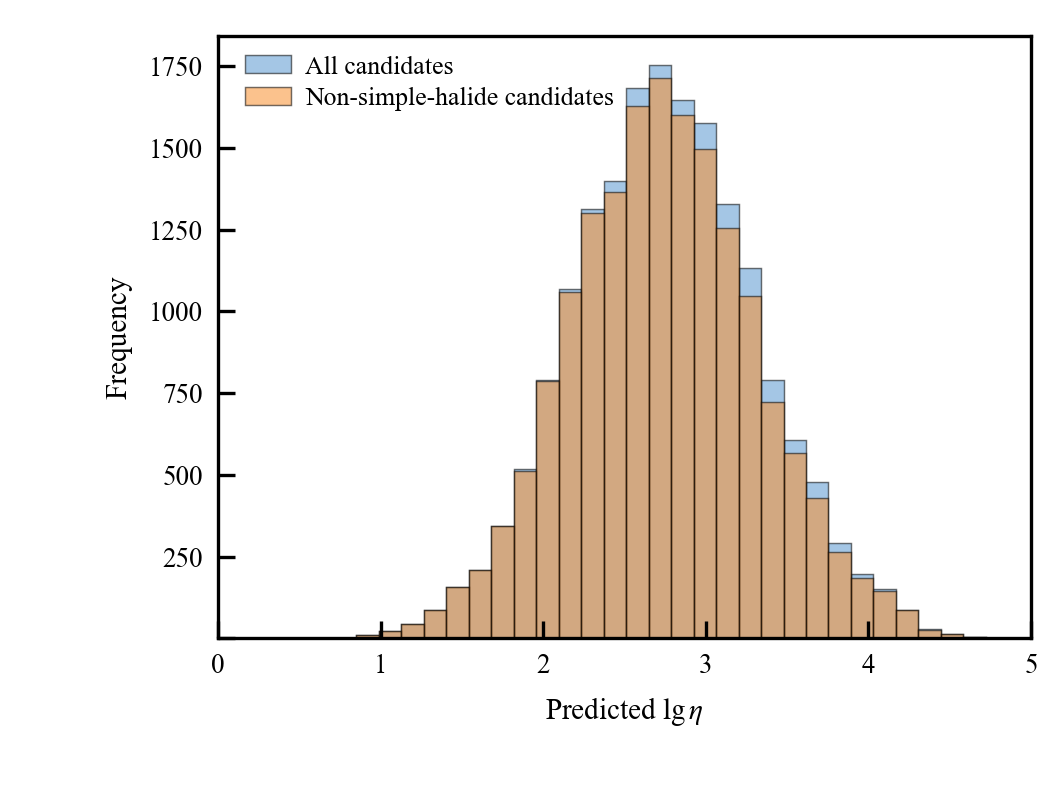

图片名称： Predicted_lg_eta_distribution_all_and_nonhalide_candidates
使用角色： backup_single_figure
最终尺寸： 90 mm × 68 mm
预计PNG像素： 1063 × 803 px
保存根目录： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\figures


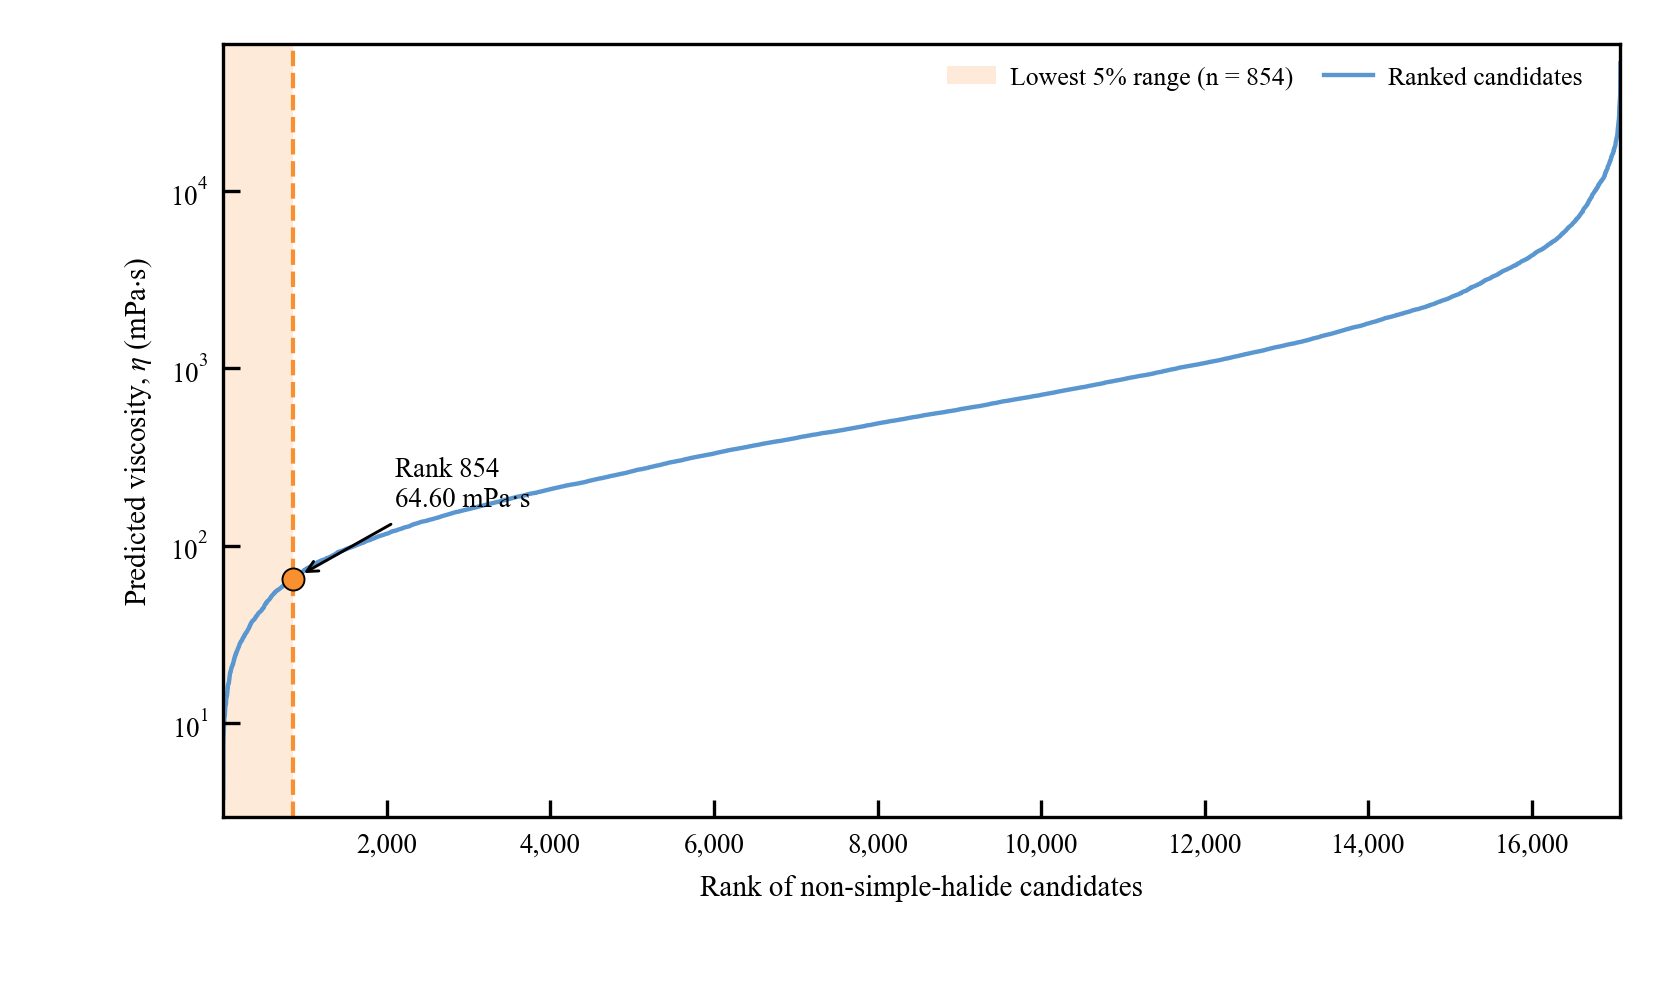

图片名称： Nonhalide_candidates_predicted_viscosity_ranking_and_lowest5pct_range
使用角色： backup_single_figure
最终尺寸： 140 mm × 85 mm
预计PNG像素： 1654 × 1004 px
保存根目录： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\figures


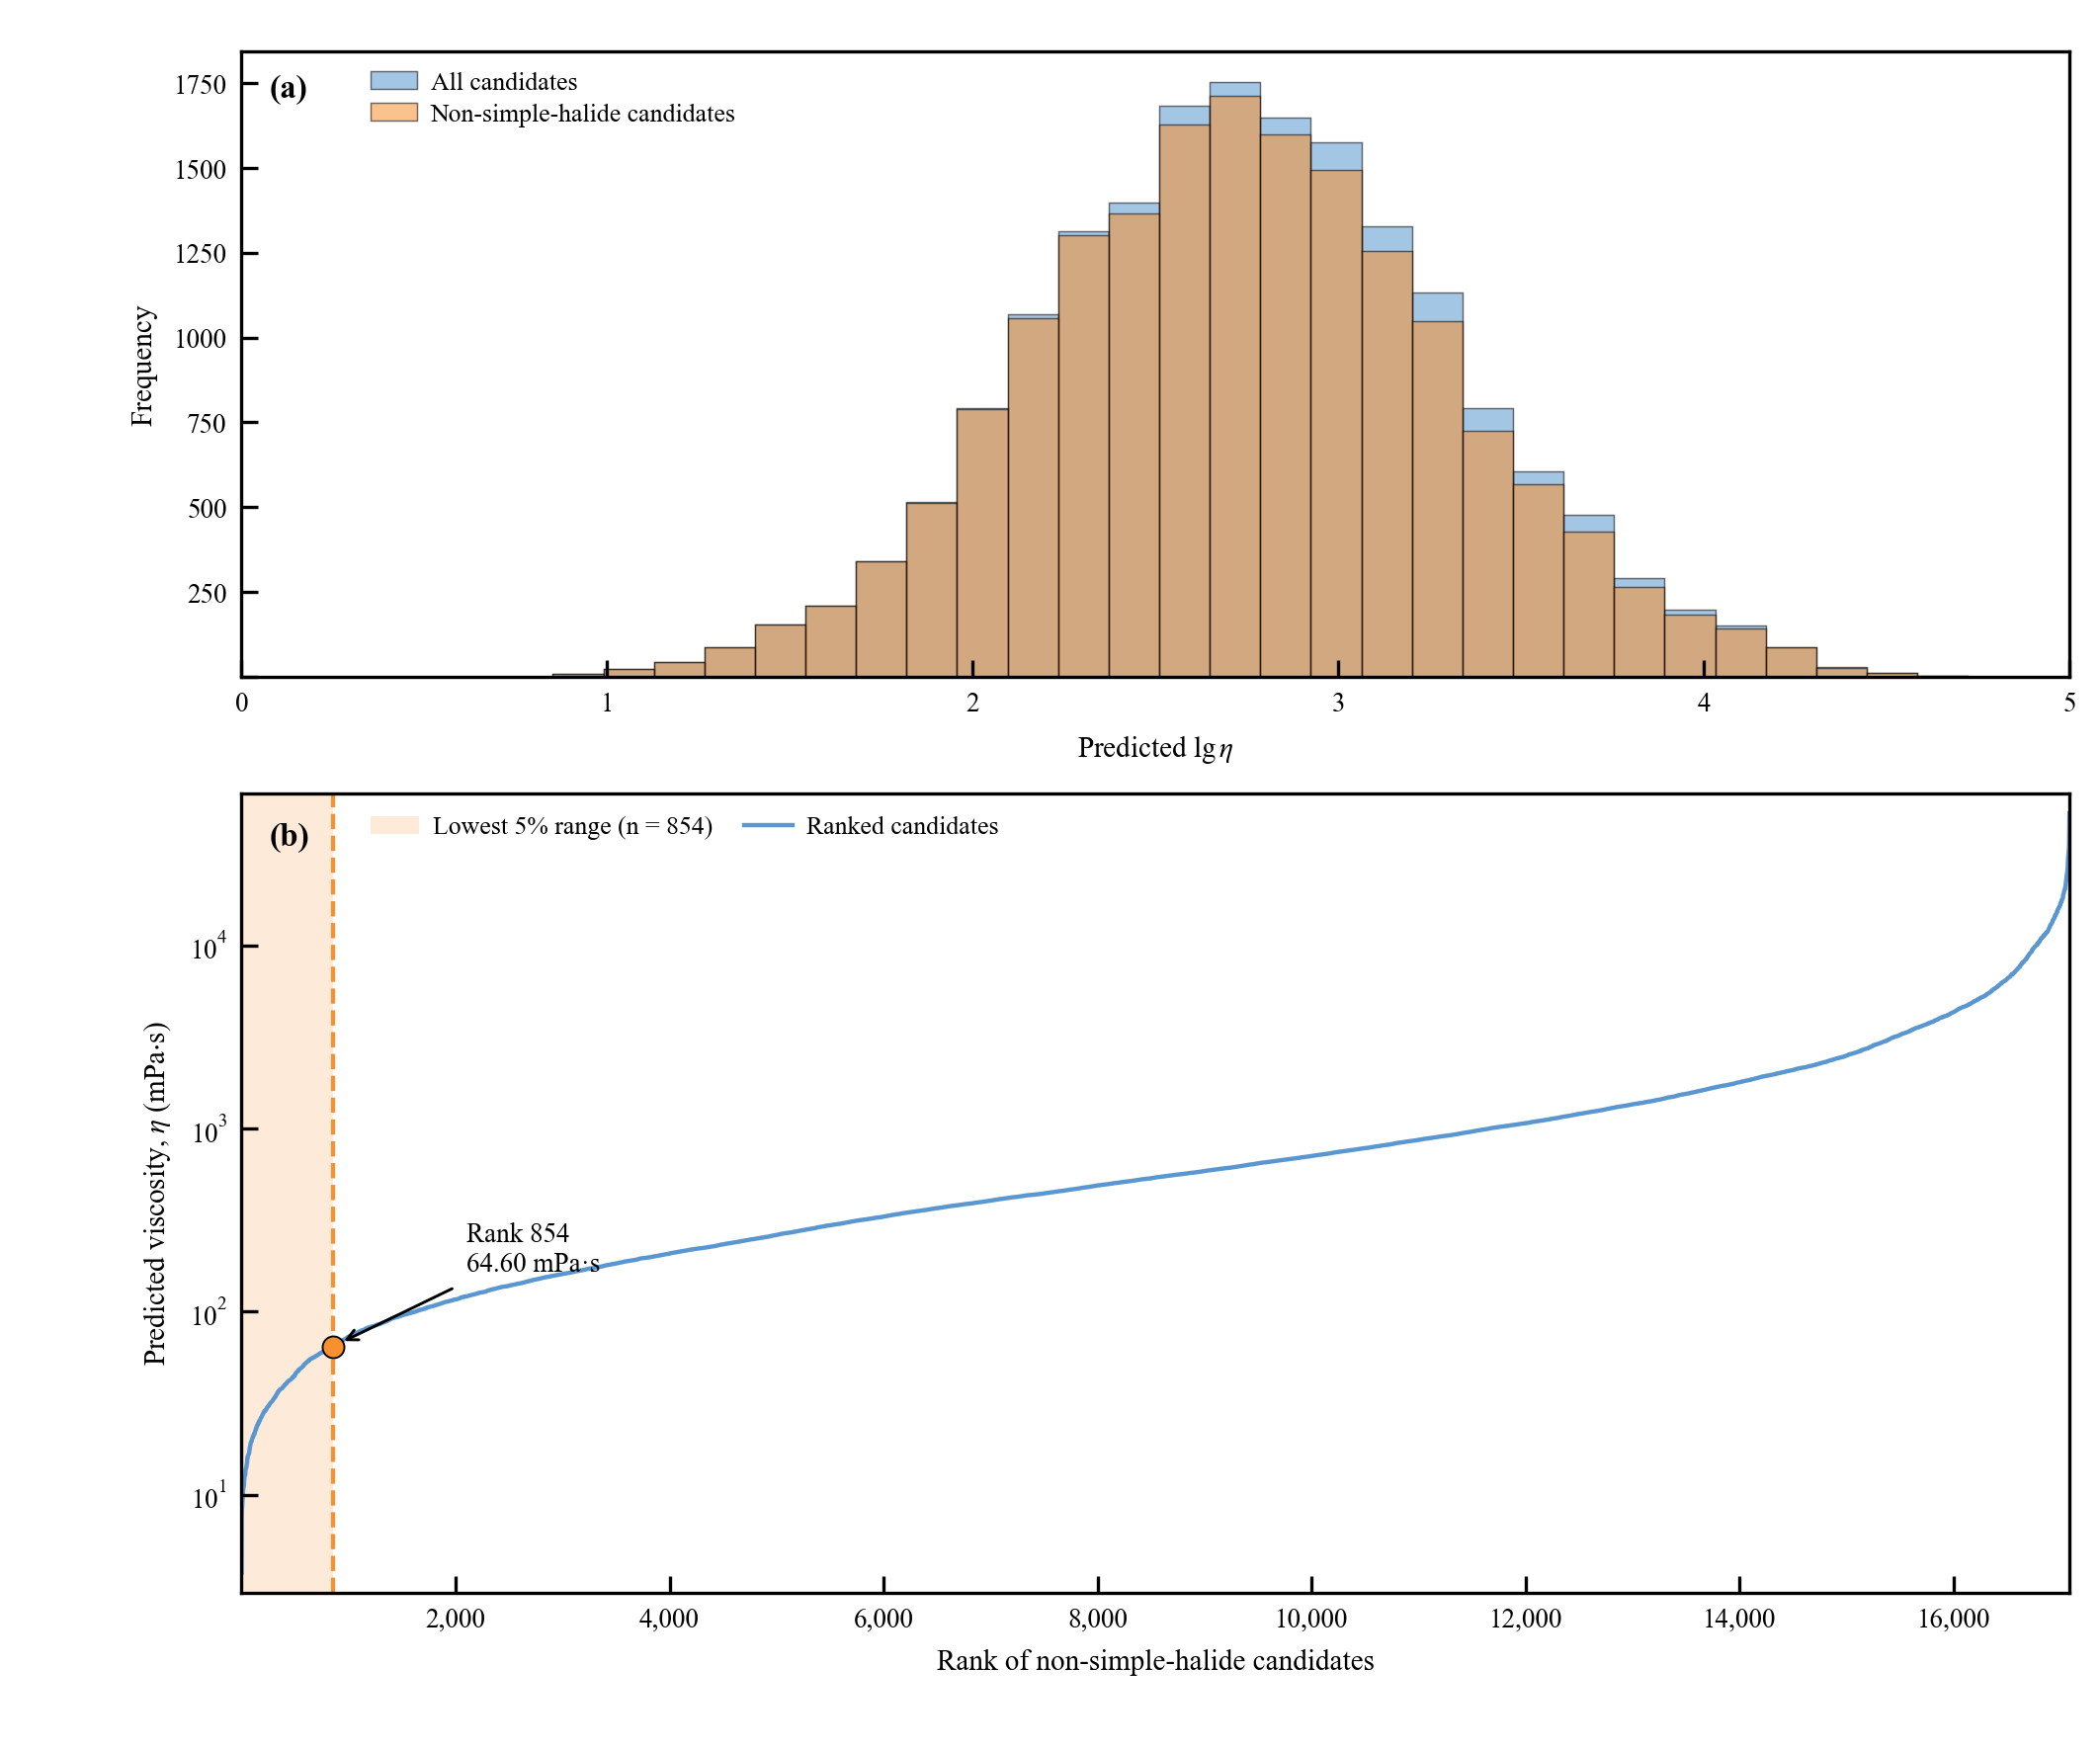

图片名称： Virtual_IL_viscosity_distribution_and_lowest5pct_screening_combined
使用角色： main_text_combined_figure
最终尺寸： 180 mm × 150 mm
面板外框间距： 10.0 mm
预计PNG像素： 2126 × 1772 px
保存根目录： D:\jupyter\IL_ML_Project\small_paper_data\viscosity_10point_holdout\outputs\virtual_IL_lightgbm_viscosity\figures
Cell 10 单图及正文组合图生成完成 ✓
single figure 1 size               = 90 mm × 68 mm
single figure 2 size               = 140 mm × 85 mm
combined figure size               = 180 mm × 150 mm
combined panel-frame gap           = 10.0 mm
combined figure layout             = 2 rows × 1 column
axis label size                    = 7.0 pt
tick label size                    = 6.5 pt
legend size                        = 6.2 pt
annotation size                    = 6.5 pt
panel label size                   = 8.0 pt
unique figure versions             = 3
backup single figures              = 2
main-text combined figures         = 1
formats per figure                 = 4
total figure/data files            = 12
lowest 5% bounda

,figure_stem,figure_category,usage_role,figure_width_mm,figure_height_mm,panel_gap_mm,axis_label_size_pt,tick_label_size_pt,legend_size_pt,expected_png_width_px,...,pdf,csv,png_sha256,svg_sha256,pdf_sha256,csv_sha256,grid_lines_visible,title_embedded_in_figure,all_legends_inside_axes,displayed_in_notebook
0,Predicted_lg_eta_distribution_all_and_nonhalid...,predicted_lg_eta_distribution,backup_single_figure,90.0,68.0,NaN,7.0,6.5,6.2,1063,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,823a98d4aaffe5103674f9d44a53e62579a2c26778b105...,b675644d6712aa6aadb4d51b2ffbad0181924a3f401f9c...,727d031ca6352b8f557df93e894f5b75b00e9eb84e6292...,d19499bf1cc787ffe1af556f63763e4f0fa9fa8dd223c9...,False,False,True,True
1,Nonhalide_candidates_predicted_viscosity_ranki...,nonhalide_viscosity_ranking_lowest5pct_range,backup_single_figure,140.0,85.0,NaN,7.0,6.5,6.2,1654,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,ee9cf43cfa12efb39fd178af58e9827ab8992270b6a9ca...,895f5b1505e153027c8494575e1c4dd89fc06a7b93f4d1...,1ff9b28103eea9ceebd3eff5e2ad4f4e5bf2c50e420fc0...,9c5c0491add1c45fff9ccc9cc026c00427b249ae2f60a8...,False,False,True,True
2,Virtual_IL_viscosity_distribution_and_lowest5p...,combined_viscosity_distribution_and_lowest5pct...,main_text_combined_figure,180.0,150.0,10.0,7.0,6.5,6.2,2126,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,21b6667ac540679e7932952b3f36093699464053b15a55...,e94b203aa5a17bbe01c0e675205cc2b860930274eb5a78...,ce4e5dc1aaddad2f7b2bb269948156efdf4a8503bf323f...,75ab0877a332d2a820a94e81f11ff28058240de1f3b822...,False,False,True,True


In [19]:
# Cell 10 | 输出单图及正文用组合图

from matplotlib.ticker import (
    FuncFormatter,
    LogFormatterMathtext,
    LogLocator,
    NullLocator,
)

# ============================================================
# 1. 图形尺寸与文字参数
# ============================================================

MM_PER_INCH = 25.4

# 单图1：预测lgη分布图
FIGURE_1_WIDTH_MM = 90.0
FIGURE_1_HEIGHT_MM = 68.0

# 单图2：候选排序及最低5%边界图
FIGURE_2_WIDTH_MM = 140.0
FIGURE_2_HEIGHT_MM = 85.0

# 正文组合图：上下排列
COMBINED_WIDTH_MM = 180.0
COMBINED_HEIGHT_MM = 150.0

# 组合图两个坐标轴外框之间的垂直距离
COMBINED_PANEL_GAP_MM = 10.0

FIGURE_1_SIZE = (
    FIGURE_1_WIDTH_MM / MM_PER_INCH,
    FIGURE_1_HEIGHT_MM / MM_PER_INCH,
)

FIGURE_2_SIZE = (
    FIGURE_2_WIDTH_MM / MM_PER_INCH,
    FIGURE_2_HEIGHT_MM / MM_PER_INCH,
)

COMBINED_SIZE = (
    COMBINED_WIDTH_MM / MM_PER_INCH,
    COMBINED_HEIGHT_MM / MM_PER_INCH,
)

# 最终版面尺寸下的文字大小
AXIS_LABEL_SIZE = 7.0
TICK_LABEL_SIZE = 6.5
LEGEND_SIZE = 6.2
ANNOTATION_SIZE = 6.5
PANEL_LABEL_SIZE = 8.0

AXIS_LINE_WIDTH = 0.8
MAJOR_TICK_WIDTH = 0.8
MINOR_TICK_WIDTH = 0.6
CURVE_LINE_WIDTH = 1.05
BOUNDARY_LINE_WIDTH = 1.0

FIGURE_RECORDS = []


# ============================================================
# 2. 四种格式保存函数
# ============================================================

def save_figure_four_formats(
    figure,
    file_stem,
    data_df,
    figure_category,
    figure_width_mm,
    figure_height_mm,
    usage_role,
    panel_gap_mm=None,
):
    """
    按指定的最终物理尺寸输出PNG、SVG、PDF和绘图数据CSV。
    """

    png_path = PNG_DIR / f"{file_stem}.png"
    svg_path = SVG_DIR / f"{file_stem}.svg"
    pdf_path = PDF_DIR / f"{file_stem}.pdf"
    csv_path = CSV_DIR / f"{file_stem}.csv"

    figure_size_inches = (
        figure_width_mm / MM_PER_INCH,
        figure_height_mm / MM_PER_INCH,
    )

    figure.set_size_inches(
        *figure_size_inches,
        forward=True,
    )

    figure.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=None,
        pad_inches=0,
        facecolor="white",
    )

    figure.savefig(
        svg_path,
        bbox_inches=None,
        pad_inches=0,
        facecolor="white",
    )

    figure.savefig(
        pdf_path,
        bbox_inches=None,
        pad_inches=0,
        facecolor="white",
    )

    save_csv_atomic(
        data_df,
        csv_path,
    )

    expected_width_px = int(
        round(
            figure_width_mm
            / MM_PER_INCH
            * DPI
        )
    )

    expected_height_px = int(
        round(
            figure_height_mm
            / MM_PER_INCH
            * DPI
        )
    )

    record = {
        "figure_stem": file_stem,
        "figure_category": figure_category,
        "usage_role": usage_role,
        "figure_width_mm": float(
            figure_width_mm
        ),
        "figure_height_mm": float(
            figure_height_mm
        ),
        "panel_gap_mm": (
            float(panel_gap_mm)
            if panel_gap_mm is not None
            else np.nan
        ),
        "axis_label_size_pt": float(
            AXIS_LABEL_SIZE
        ),
        "tick_label_size_pt": float(
            TICK_LABEL_SIZE
        ),
        "legend_size_pt": float(
            LEGEND_SIZE
        ),
        "expected_png_width_px": (
            expected_width_px
        ),
        "expected_png_height_px": (
            expected_height_px
        ),
        "png_dpi": int(DPI),
        "png": str(png_path),
        "svg": str(svg_path),
        "pdf": str(pdf_path),
        "csv": str(csv_path),
        "png_sha256": sha256_file(
            png_path
        ),
        "svg_sha256": sha256_file(
            svg_path
        ),
        "pdf_sha256": sha256_file(
            pdf_path
        ),
        "csv_sha256": sha256_file(
            csv_path
        ),
        "grid_lines_visible": False,
        "title_embedded_in_figure": False,
        "all_legends_inside_axes": True,
        "displayed_in_notebook": True,
    }

    FIGURE_RECORDS.append(
        record
    )

    plt.close(
        figure
    )

    display(
        Image(
            filename=str(png_path)
        )
    )

    print(
        "图片名称：",
        file_stem,
    )

    print(
        "使用角色：",
        usage_role,
    )

    print(
        "最终尺寸：",
        (
            f"{figure_width_mm:.0f} mm × "
            f"{figure_height_mm:.0f} mm"
        ),
    )

    if panel_gap_mm is not None:
        print(
            "面板外框间距：",
            f"{panel_gap_mm:.1f} mm",
        )

    print(
        "预计PNG像素：",
        (
            f"{expected_width_px} × "
            f"{expected_height_px} px"
        ),
    )

    print(
        "保存根目录：",
        FIG_DIR,
    )

    return record


# ============================================================
# 3. 坐标轴统一格式
# ============================================================

def format_axes_consistently(
    axis,
):
    """
    统一坐标轴外框、刻度方向、字号和线宽。
    """

    for spine in axis.spines.values():
        spine.set_visible(
            True
        )

        spine.set_linewidth(
            AXIS_LINE_WIDTH
        )

        spine.set_zorder(
            20
        )

    axis.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=4.0,
        width=MAJOR_TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        top=False,
        right=False,
    )

    axis.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=2.5,
        width=MINOR_TICK_WIDTH,
        top=False,
        right=False,
    )

    axis.xaxis.set_zorder(
        21
    )

    axis.yaxis.set_zorder(
        21
    )


def hide_y_axis_zero(
    value,
    position,
):
    return (
        ""
        if np.isclose(
            value,
            0.0,
        )
        else f"{value:g}"
    )


def format_integer_with_commas(
    value,
    position,
):
    return (
        f"{int(round(value)):,}"
    )


def add_panel_label(
    axis,
    panel_label,
):
    """
    在多面板图左上角添加面板编号。
    """

    axis.text(
        0.015,
        0.965,
        panel_label,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        fontstyle="normal",
        zorder=30,
    )


# ============================================================
# 4. 作图对象检查
# ============================================================

required_plot_objects = {
    "pred_df": pred_df,
    "nonhalide_df": nonhalide_df,
    "lowest5_df": lowest5_df,
    "lowest5_boundary_audit_df": (
        lowest5_boundary_audit_df
    ),
}

for (
    object_name,
    dataframe,
) in required_plot_objects.items():

    if dataframe.empty:
        raise RuntimeError(
            f"作图所需的"
            f"{object_name}为空。"
        )

if (
    len(nonhalide_df)
    != EXPECTED_NONHALIDE_COUNT
):
    raise RuntimeError(
        "作图时非简单卤素候选"
        "数量不是17082。"
    )

if (
    len(lowest5_df)
    != EXPECTED_LOWEST5_COUNT
):
    raise RuntimeError(
        "作图时最低5%正式候选"
        "数量不是854。"
    )

if (
    lowest5_count
    != EXPECTED_LOWEST5_COUNT
):
    raise RuntimeError(
        "最低5%边界排名不是854。"
    )

if not np.isclose(
    boundary_eta,
    EXPECTED_LOWEST5_MAX_ETA,
    rtol=0.0,
    atol=BOUNDARY_TOLERANCE,
):
    raise RuntimeError(
        "作图时最低5%预测黏度上限"
        "不是最终审计值。"
    )


# ============================================================
# 5. 清理废弃的Top20图片及绘图数据
# ============================================================

legacy_figure_stem = (
    "Top20_nonhalide_candidates_"
    "predicted_viscosity"
)

legacy_figure_paths = [
    (
        PNG_DIR
        / f"{legacy_figure_stem}.png"
    ),
    (
        SVG_DIR
        / f"{legacy_figure_stem}.svg"
    ),
    (
        PDF_DIR
        / f"{legacy_figure_stem}.pdf"
    ),
    (
        CSV_DIR
        / f"{legacy_figure_stem}.csv"
    ),
]

removed_legacy_figures = []

for legacy_path in legacy_figure_paths:

    if legacy_path.exists():
        legacy_path.unlink()

        removed_legacy_figures.append(
            str(legacy_path)
        )


# ============================================================
# 6. 准备分布图所需数据
# ============================================================

if (
    pred_df["pred_lg_eta"].min()
    < 0.0
    or pred_df["pred_lg_eta"].max()
    > 5.0
):
    raise RuntimeError(
        "预测lgη超出固定绘图范围0—5，"
        "不能在不说明的情况下截断。"
    )

histogram_bins = (
    np.histogram_bin_edges(
        pred_df[
            "pred_lg_eta"
        ].to_numpy(
            dtype=float
        ),
        bins=30,
    )
)

figure_1_data = pd.concat(
    [
        pred_df[
            [
                "virtual_IL_key",
                "pred_lg_eta",
                "pred_eta_mPa_s",
            ]
        ].assign(
            candidate_set="All"
        ),

        nonhalide_df[
            [
                "virtual_IL_key",
                "pred_lg_eta",
                "pred_eta_mPa_s",
            ]
        ].assign(
            candidate_set=(
                "Non-simple-halide"
            )
        ),
    ],
    ignore_index=True,
)


# ============================================================
# 7. 准备排序图所需数据
# ============================================================

plot_df = (
    nonhalide_df[
        [
            "rank_viscosity_nonhalide",
            "virtual_IL_key",
            "cation_smiles",
            "anion_smiles",
            "T_pred_K",
            "P_pred_bar",
            "pred_lg_eta",
            "pred_eta_mPa_s",
        ]
    ]
    .copy()
    .sort_values(
        "rank_viscosity_nonhalide",
        ascending=True,
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

plot_df[
    "is_lowest5pct"
] = (
    plot_df[
        "rank_viscosity_nonhalide"
    ]
    <= lowest5_count
)

plot_df[
    "candidate_range"
] = np.where(
    plot_df[
        "is_lowest5pct"
    ],
    "Lowest 5%",
    "Remaining 95%",
)

plot_df[
    "selection_fraction"
] = LOWEST_FRACTION

plot_df[
    "selection_rounding_rule"
] = "floor"

plot_df[
    "selection_boundary_rank"
] = lowest5_count

plot_df[
    "selection_boundary_eta_mPa_s"
] = boundary_eta

rank_values = plot_df[
    "rank_viscosity_nonhalide"
].to_numpy(
    dtype=float
)

eta_values = plot_df[
    "pred_eta_mPa_s"
].to_numpy(
    dtype=float
)

if not np.all(
    np.diff(
        rank_values
    )
    == 1
):
    raise RuntimeError(
        "非简单卤素候选排名不是"
        "1—17082连续整数。"
    )

if not np.all(
    np.diff(
        eta_values
    )
    >= 0.0
):
    raise RuntimeError(
        "非简单卤素候选预测黏度"
        "未按升序排列。"
    )

if (
    eta_values
    <= 0.0
).any():
    raise RuntimeError(
        "对数纵坐标不能包含"
        "非正预测黏度。"
    )


# ============================================================
# 8. 定义两个面板的绘制函数
# ============================================================

def draw_distribution_panel(
    axis,
    show_panel_label=False,
    legend_anchor_x=0.02,
):
    """
    绘制全部候选与非简单卤素候选的预测lgη分布。
    """

    axis.hist(
        pred_df[
            "pred_lg_eta"
        ],
        bins=histogram_bins,
        alpha=0.55,
        label=(
            "All candidates"
        ),
        color=BLUE,
        edgecolor="black",
        linewidth=0.35,
        zorder=1,
    )

    axis.hist(
        nonhalide_df[
            "pred_lg_eta"
        ],
        bins=histogram_bins,
        alpha=0.55,
        label=(
            "Non-simple-halide candidates"
        ),
        color=ORANGE,
        edgecolor="black",
        linewidth=0.35,
        zorder=2,
    )

    axis.set_xlabel(
        r"Predicted $\lg\eta$",
        fontsize=AXIS_LABEL_SIZE,
    )

    axis.set_ylabel(
        "Frequency",
        fontsize=AXIS_LABEL_SIZE,
    )

    axis.set_xlim(
        0.0,
        5.0,
    )

    axis.set_xticks(
        np.arange(
            0.0,
            5.1,
            1.0,
        )
    )

    axis.yaxis.set_major_formatter(
        FuncFormatter(
            hide_y_axis_zero
        )
    )

    axis.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(
            legend_anchor_x,
            0.985,
        ),
        bbox_transform=axis.transAxes,
        borderaxespad=0.0,
        fontsize=LEGEND_SIZE,
        handlelength=1.8,
        handletextpad=0.55,
        labelspacing=0.30,
        ncol=1,
    )

    axis.grid(
        False
    )

    format_axes_consistently(
        axis
    )

    if show_panel_label:
        add_panel_label(
            axis,
            "(a)",
        )


def draw_ranking_panel(
    axis,
    show_panel_label=False,
    legend_location="upper left",
    legend_anchor_x=0.02,
):
    """
    绘制非简单卤素候选预测黏度排序及最低5%边界。
    """

    axis.axvspan(
        1,
        lowest5_count,
        color=ORANGE,
        alpha=0.18,
        linewidth=0.0,
        label=(
            f"Lowest 5% range "
            f"(n = {lowest5_count})"
        ),
        zorder=0,
    )

    axis.plot(
        rank_values,
        eta_values,
        color=BLUE,
        linewidth=CURVE_LINE_WIDTH,
        label=(
            "Ranked candidates"
        ),
        zorder=2,
    )

    axis.axvline(
        lowest5_count,
        color=ORANGE,
        linestyle="--",
        linewidth=BOUNDARY_LINE_WIDTH,
        zorder=3,
    )

    axis.scatter(
        [lowest5_count],
        [boundary_eta],
        s=28,
        color=ORANGE,
        edgecolor="black",
        linewidth=0.45,
        zorder=4,
    )

    axis.annotate(
        (
            f"Rank {lowest5_count}\n"
            f"{boundary_eta:.2f} mPa·s"
        ),
        xy=(
            lowest5_count,
            boundary_eta,
        ),
        xytext=(
            lowest5_count + 1250,
            boundary_eta * 2.4,
        ),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=ANNOTATION_SIZE,
        arrowprops={
            "arrowstyle": "->",
            "color": "black",
            "linewidth": 0.7,
            "shrinkA": 2,
            "shrinkB": 3,
        },
        zorder=5,
    )

    axis.set_yscale(
        "log",
        base=10,
    )

    axis.set_xlabel(
        (
            "Rank of non-simple-halide "
            "candidates"
        ),
        fontsize=AXIS_LABEL_SIZE,
    )

    axis.set_ylabel(
        (
            r"Predicted viscosity, "
            r"$\eta$ (mPa$\cdot$s)"
        ),
        fontsize=AXIS_LABEL_SIZE,
    )

    axis.set_xlim(
        1,
        len(plot_df),
    )

    axis.set_ylim(
        eta_values.min() * 0.78,
        eta_values.max() * 1.28,
    )

    axis.xaxis.set_major_formatter(
        FuncFormatter(
            format_integer_with_commas
        )
    )

    axis.yaxis.set_major_locator(
        LogLocator(
            base=10.0
        )
    )

    axis.yaxis.set_major_formatter(
        LogFormatterMathtext(
            base=10.0
        )
    )

    axis.yaxis.set_minor_locator(
        NullLocator()
    )

    axis.legend(
        frameon=False,
        loc=legend_location,
        bbox_to_anchor=(
            legend_anchor_x,
            0.985,
        ),
        bbox_transform=axis.transAxes,
        borderaxespad=0.0,
        fontsize=LEGEND_SIZE,
        handlelength=1.9,
        handletextpad=0.55,
        ncol=2,
        columnspacing=1.2,
    )

    axis.grid(
        False,
        which="both",
    )

    format_axes_consistently(
        axis
    )

    if show_panel_label:
        add_panel_label(
            axis,
            "(b)",
        )


# ============================================================
# 9. 输出单图1：预测lgη分布
# ============================================================

figure_1, axis_1 = plt.subplots(
    figsize=FIGURE_1_SIZE
)

draw_distribution_panel(
    axis_1,
    show_panel_label=False,
    legend_anchor_x=0.02,
)

figure_1.subplots_adjust(
    left=0.205,
    right=0.970,
    bottom=0.205,
    top=0.955,
)

figure_1_stem = (
    "Predicted_lg_eta_distribution_"
    "all_and_nonhalide_candidates"
)

save_figure_four_formats(
    figure=figure_1,
    file_stem=figure_1_stem,
    data_df=figure_1_data,
    figure_category=(
        "predicted_lg_eta_distribution"
    ),
    figure_width_mm=(
        FIGURE_1_WIDTH_MM
    ),
    figure_height_mm=(
        FIGURE_1_HEIGHT_MM
    ),
    usage_role=(
        "backup_single_figure"
    ),
)


# ============================================================
# 10. 输出单图2：排序曲线及最低5%范围
# ============================================================

figure_2, axis_2 = plt.subplots(
    figsize=FIGURE_2_SIZE
)

# 单独排序图的图例位于坐标轴内部右上角。
draw_ranking_panel(
    axis_2,
    show_panel_label=False,
    legend_location="upper right",
    legend_anchor_x=0.98,
)

figure_2.subplots_adjust(
    left=0.135,
    right=0.980,
    bottom=0.185,
    top=0.955,
)

figure_2_stem = (
    "Nonhalide_candidates_predicted_viscosity_"
    "ranking_and_lowest5pct_range"
)

save_figure_four_formats(
    figure=figure_2,
    file_stem=figure_2_stem,
    data_df=plot_df,
    figure_category=(
        "nonhalide_viscosity_ranking_"
        "lowest5pct_range"
    ),
    figure_width_mm=(
        FIGURE_2_WIDTH_MM
    ),
    figure_height_mm=(
        FIGURE_2_HEIGHT_MM
    ),
    usage_role=(
        "backup_single_figure"
    ),
)


# ============================================================
# 11. 输出正文组合图
# ============================================================

COMBINED_LEFT = 0.115
COMBINED_RIGHT = 0.985
COMBINED_BOTTOM = 0.090
COMBINED_TOP = 0.970

combined_axes_width = (
    COMBINED_RIGHT
    - COMBINED_LEFT
)

combined_total_height = (
    COMBINED_TOP
    - COMBINED_BOTTOM
)

combined_gap_fraction = (
    COMBINED_PANEL_GAP_MM
    / COMBINED_HEIGHT_MM
)

combined_axes_height = (
    combined_total_height
    - combined_gap_fraction
)

combined_height_ratio_a = 0.90
combined_height_ratio_b = 1.15

combined_ratio_total = (
    combined_height_ratio_a
    + combined_height_ratio_b
)

combined_axis_a_height = (
    combined_axes_height
    * combined_height_ratio_a
    / combined_ratio_total
)

combined_axis_b_height = (
    combined_axes_height
    * combined_height_ratio_b
    / combined_ratio_total
)

combined_axis_b_bottom = (
    COMBINED_BOTTOM
)

combined_axis_a_bottom = (
    combined_axis_b_bottom
    + combined_axis_b_height
    + combined_gap_fraction
)

figure_3 = plt.figure(
    figsize=COMBINED_SIZE
)

axis_3a = figure_3.add_axes(
    [
        COMBINED_LEFT,
        combined_axis_a_bottom,
        combined_axes_width,
        combined_axis_a_height,
    ]
)

axis_3b = figure_3.add_axes(
    [
        COMBINED_LEFT,
        combined_axis_b_bottom,
        combined_axes_width,
        combined_axis_b_height,
    ]
)

draw_distribution_panel(
    axis_3a,
    show_panel_label=True,
    legend_anchor_x=0.065,
)

draw_ranking_panel(
    axis_3b,
    show_panel_label=True,
    legend_location="upper left",
    legend_anchor_x=0.065,
)

combined_figure_data = pd.concat(
    [
        figure_1_data.assign(
            panel="a",
            panel_description=(
                "Predicted lg eta distribution"
            ),
        ),

        plot_df.assign(
            panel="b",
            panel_description=(
                "Ranked viscosity and "
                "lowest 5 percent range"
            ),
        ),
    ],
    ignore_index=True,
    sort=False,
)

figure_3_stem = (
    "Virtual_IL_viscosity_distribution_"
    "and_lowest5pct_screening_combined"
)

save_figure_four_formats(
    figure=figure_3,
    file_stem=figure_3_stem,
    data_df=combined_figure_data,
    figure_category=(
        "combined_viscosity_distribution_"
        "and_lowest5pct_screening"
    ),
    figure_width_mm=(
        COMBINED_WIDTH_MM
    ),
    figure_height_mm=(
        COMBINED_HEIGHT_MM
    ),
    usage_role=(
        "main_text_combined_figure"
    ),
    panel_gap_mm=(
        COMBINED_PANEL_GAP_MM
    ),
)


# ============================================================
# 12. 更新图片清单
# ============================================================

figure_manifest_df = pd.DataFrame(
    FIGURE_RECORDS
)

figure_manifest_path = (
    FIG_DIR
    / "virtual_viscosity_figure_manifest.csv"
)

if (
    len(figure_manifest_df)
    != 3
):
    raise RuntimeError(
        "当前应输出2张备用单图和"
        "1张正文组合图，"
        "但图片清单数量不是3。"
    )

expected_figure_stems = {
    figure_1_stem,
    figure_2_stem,
    figure_3_stem,
}

actual_figure_stems = set(
    figure_manifest_df[
        "figure_stem"
    ].astype(str)
)

if (
    actual_figure_stems
    != expected_figure_stems
):
    raise RuntimeError(
        "单图和组合图的图片清单"
        "与预期不一致。"
    )

usage_role_counts = (
    figure_manifest_df[
        "usage_role"
    ]
    .value_counts()
    .to_dict()
)

if (
    usage_role_counts.get(
        "backup_single_figure",
        0,
    )
    != 2
):
    raise RuntimeError(
        "备用单图数量不是2。"
    )

if (
    usage_role_counts.get(
        "main_text_combined_figure",
        0,
    )
    != 1
):
    raise RuntimeError(
        "正文组合图数量不是1。"
    )

if not (
    figure_manifest_df[
        "all_legends_inside_axes"
    ].all()
):
    raise RuntimeError(
        "存在位于坐标轴外部的图例。"
    )

save_csv_atomic(
    figure_manifest_df,
    figure_manifest_path,
)


# ============================================================
# 13. 输出运行结果
# ============================================================

print(
    "=" * 108
)

print(
    "Cell 10 单图及正文组合图生成完成 ✓"
)

print(
    "=" * 108
)

print(
    "single figure 1 size               =",
    (
        f"{FIGURE_1_WIDTH_MM:.0f} mm × "
        f"{FIGURE_1_HEIGHT_MM:.0f} mm"
    ),
)

print(
    "single figure 2 size               =",
    (
        f"{FIGURE_2_WIDTH_MM:.0f} mm × "
        f"{FIGURE_2_HEIGHT_MM:.0f} mm"
    ),
)

print(
    "combined figure size               =",
    (
        f"{COMBINED_WIDTH_MM:.0f} mm × "
        f"{COMBINED_HEIGHT_MM:.0f} mm"
    ),
)

print(
    "combined panel-frame gap           =",
    f"{COMBINED_PANEL_GAP_MM:.1f} mm",
)

print(
    "combined figure layout             =",
    "2 rows × 1 column",
)

print(
    "axis label size                    =",
    f"{AXIS_LABEL_SIZE:.1f} pt",
)

print(
    "tick label size                    =",
    f"{TICK_LABEL_SIZE:.1f} pt",
)

print(
    "legend size                        =",
    f"{LEGEND_SIZE:.1f} pt",
)

print(
    "annotation size                    =",
    f"{ANNOTATION_SIZE:.1f} pt",
)

print(
    "panel label size                   =",
    f"{PANEL_LABEL_SIZE:.1f} pt",
)

print(
    "unique figure versions             =",
    len(figure_manifest_df),
)

print(
    "backup single figures              =",
    2,
)

print(
    "main-text combined figures         =",
    1,
)

print(
    "formats per figure                 =",
    4,
)

print(
    "total figure/data files            =",
    len(figure_manifest_df) * 4,
)

print(
    "lowest 5% boundary rank            =",
    lowest5_count,
)

print(
    "lowest 5% upper eta (mPa·s)        =",
    f"{boundary_eta:.6f}",
)

print(
    "ranking-curve y scale              =",
    "log10",
)

print(
    "minor y ticks visible              =",
    False,
)

print(
    "single ranking legend              =",
    "inside upper right",
)

print(
    "combined ranking legend            =",
    "inside upper left",
)

print(
    "all legends inside axes            =",
    True,
)

print(
    "grid lines visible                 =",
    False,
)

print(
    "embedded figure titles             =",
    False,
)

print(
    "panel labels in combined figure    =",
    "(a), (b)",
)

print(
    "figures displayed in notebook      =",
    True,
)

print(
    "removed legacy Top20 figure files  =",
    len(removed_legacy_figures),
)

print(
    "figure manifest                    =",
    figure_manifest_path,
)

print(
    "\n正文建议使用的组合图："
)

print(
    PNG_DIR
    / (
        "Virtual_IL_viscosity_distribution_"
        "and_lowest5pct_screening_combined.png"
    )
)

display(
    figure_manifest_df
)

In [21]:
# Cell 11 | 完成虚拟IL候选库、最低5%筛选与冻结LightGBM预测最终审计

from PIL import Image as PILImage

check_items = []


def add_check(
    stage,
    path,
    required=True,
    note="",
):
    path = Path(path)

    check_items.append({
        "stage": stage,
        "file_name": path.name,
        "path": str(path),
        "required": bool(required),
        "exists": path.exists(),
        "size_bytes": (
            int(path.stat().st_size)
            if path.exists()
            else 0
        ),
        "sha256": (
            sha256_file(path)
            if path.exists()
            else None
        ),
        "note": note,
    })


# ============================================================
# 1. 冻结输入文件检查
# ============================================================

for input_path, note in [
    (
        ML_READY_PATH,
        "全开发集来源表",
    ),
    (
        MPNN_MODEL_PATH,
        "冻结MPNN特征提取器",
    ),
    (
        TP_SCALER_PATH,
        "冻结温压标准化器",
    ),
    (
        MPNN_METADATA_PATH,
        "MPNN元数据",
    ),
    (
        FINAL_LGBM_PATH,
        "冻结最终LightGBM",
    ),
    (
        FINAL_SCALER_PATH,
        "冻结下游特征标准化器",
    ),
    (
        FINAL_PARAMETER_PATH,
        "最终LightGBM参数",
    ),
    (
        FINAL_FREEZE_MANIFEST_PATH,
        "最终模型冻结manifest",
    ),
    (
        LOCKED10_FINAL_MANIFEST_PATH,
        "锁定10点补充验证manifest",
    ),
]:
    add_check(
        "Frozen input",
        input_path,
        True,
        note,
    )


# ============================================================
# 2. Cell 0—Cell 9输出文件检查
# ============================================================

add_check(
    "Cell 0",
    CELL0_AUDIT_PATH,
    True,
)

# Cell 1
for path in [
    (
        TABLE_DIR
        / "source_ILs_for_virtual_generation.csv"
    ),
    (
        TABLE_DIR
        / "source_cation_frequency.csv"
    ),
    (
        TABLE_DIR
        / "source_anion_frequency.csv"
    ),
    (
        TABLE_DIR
        / "source_ILs_invalid_after_canonicalization.csv"
    ),
    (
        LOG_DIR
        / "source_ion_provenance.json"
    ),
]:
    add_check(
        "Cell 1",
        path,
        True,
    )

# Cell 2
for path in [
    (
        TABLE_DIR
        / "virtual_IL_library.csv"
    ),
    (
        LOG_DIR
        / "virtual_IL_generation_audit.json"
    ),
]:
    add_check(
        "Cell 2",
        path,
        True,
    )

# Cell 3
for path in [
    (
        TABLE_DIR
        / "virtual_IL_library_before_reasonability_filter.csv"
    ),
    (
        TABLE_DIR
        / "virtual_IL_library_after_reasonability_filter.csv"
    ),
    (
        TABLE_DIR
        / "virtual_IL_library_removed_by_reasonability_filter.csv"
    ),
    (
        TABLE_DIR
        / "virtual_IL_reasonability_filter_reason_summary.csv"
    ),
    (
        LOG_DIR
        / "virtual_IL_reasonability_filter_audit.json"
    ),
]:
    add_check(
        "Cell 3",
        path,
        True,
    )

# Cell 4
for path in [
    (
        FEATURE_DIR
        / "virtual_cation_graphs.pt"
    ),
    (
        FEATURE_DIR
        / "virtual_anion_graphs.pt"
    ),
    (
        TABLE_DIR
        / "virtual_IL_library_graph_valid.csv"
    ),
    (
        TABLE_DIR
        / "virtual_IL_invalid_graphs.csv"
    ),
    (
        LOG_DIR
        / "virtual_IL_graph_generation_audit.json"
    ),
]:
    add_check(
        "Cell 4",
        path,
        True,
    )

# Cell 5
add_check(
    "Cell 5",
    MPNN_LOAD_AUDIT_PATH,
    True,
)

# Cell 6
for path in [
    (
        FEATURE_DIR
        / "virtual_mpnn_features_viscosity.npy"
    ),
    (
        FEATURE_DIR
        / "virtual_mpnn_feature_manifest.csv"
    ),
    (
        FEATURE_DIR
        / "virtual_mpnn_feature_summary.csv"
    ),
    (
        LOG_DIR
        / "virtual_mpnn_feature_generation_audit.json"
    ),
]:
    add_check(
        "Cell 6",
        path,
        True,
    )

# Cell 7
for path in [
    MODEL_REGISTRY_PATH,
    MODEL_LOAD_AUDIT_PATH,
]:
    add_check(
        "Cell 7",
        path,
        True,
    )

# Cell 8
for path in [
    (
        FEATURE_DIR
        / "virtual_mpnn_features_scaled_for_frozen_LightGBM.npy"
    ),
    (
        LOG_DIR
        / "virtual_IL_frozen_LightGBM_prediction_manifest.json"
    ),
    *output_tables.values(),
]:
    add_check(
        "Cell 8",
        path,
        True,
    )

# Cell 9
for path in [
    (
        TABLE_DIR
        / "virtual_IL_viscosity_prediction_range_audit.csv"
    ),
    (
        TABLE_DIR
        / "external10_LGBM_Transformer_validation_summary_provenance.csv"
    ),
    (
        LOG_DIR
        / "external10_validation_provenance.json"
    ),
]:
    add_check(
        "Cell 9",
        path,
        True,
    )


# ============================================================
# 3. Cell 10三组图片及绘图数据检查
# ============================================================

figure_stems = [
    (
        "Predicted_lg_eta_distribution_"
        "all_and_nonhalide_candidates"
    ),
    (
        "Nonhalide_candidates_predicted_viscosity_"
        "ranking_and_lowest5pct_range"
    ),
    (
        "Virtual_IL_viscosity_distribution_"
        "and_lowest5pct_screening_combined"
    ),
]

expected_figure_specs = {
    figure_stems[0]: {
        "usage_role": "backup_single_figure",
        "width_mm": 90.0,
        "height_mm": 68.0,
        "panel_gap_mm": None,
    },
    figure_stems[1]: {
        "usage_role": "backup_single_figure",
        "width_mm": 140.0,
        "height_mm": 85.0,
        "panel_gap_mm": None,
    },
    figure_stems[2]: {
        "usage_role": "main_text_combined_figure",
        "width_mm": 180.0,
        "height_mm": 150.0,
        "panel_gap_mm": 10.0,
    },
}

for figure_stem in figure_stems:
    for directory, suffix in [
        (
            PNG_DIR,
            ".png",
        ),
        (
            SVG_DIR,
            ".svg",
        ),
        (
            PDF_DIR,
            ".pdf",
        ),
        (
            CSV_DIR,
            ".csv",
        ),
    ]:
        add_check(
            "Cell 10",
            directory
            / f"{figure_stem}{suffix}",
            True,
        )

add_check(
    "Cell 10",
    figure_manifest_path,
    True,
)


# ============================================================
# 4. 废弃Top20、Top50和Top100输出清理审计
# ============================================================

legacy_top_paths = [
    (
        TABLE_DIR
        / "top20_virtual_IL_candidates_low_viscosity_all.csv"
    ),
    (
        TABLE_DIR
        / "top50_virtual_IL_candidates_low_viscosity_all.csv"
    ),
    (
        TABLE_DIR
        / "top100_virtual_IL_candidates_low_viscosity_all.csv"
    ),
    (
        TABLE_DIR
        / "top20_virtual_IL_candidates_low_viscosity_nonhalide.csv"
    ),
    (
        TABLE_DIR
        / "top50_virtual_IL_candidates_low_viscosity_nonhalide.csv"
    ),
    (
        TABLE_DIR
        / "top100_virtual_IL_candidates_low_viscosity_nonhalide.csv"
    ),
    (
        PNG_DIR
        / "Top20_nonhalide_candidates_predicted_viscosity.png"
    ),
    (
        SVG_DIR
        / "Top20_nonhalide_candidates_predicted_viscosity.svg"
    ),
    (
        PDF_DIR
        / "Top20_nonhalide_candidates_predicted_viscosity.pdf"
    ),
    (
        CSV_DIR
        / "Top20_nonhalide_candidates_predicted_viscosity.csv"
    ),
]

legacy_cleanup_df = pd.DataFrame([
    {
        "file_name": path.name,
        "path": str(path),
        "exists_after_cleanup": (
            path.exists()
        ),
        "removed_successfully": (
            not path.exists()
        ),
    }
    for path in legacy_top_paths
])

legacy_cleanup_path = (
    TABLE_DIR
    / "deprecated_top_output_cleanup_audit.csv"
)

save_csv_atomic(
    legacy_cleanup_df,
    legacy_cleanup_path,
)

add_check(
    "Deprecated output audit",
    legacy_cleanup_path,
    True,
)

remaining_legacy_paths = [
    path
    for path in legacy_top_paths
    if path.exists()
]

if remaining_legacy_paths:
    raise RuntimeError(
        "仍存在已废弃的Top20、Top50或Top100输出：\n"
        + "\n".join(
            map(
                str,
                remaining_legacy_paths,
            )
        )
    )


# ============================================================
# 5. 必要输出存在性和非空检查
# ============================================================

check_df = pd.DataFrame(
    check_items
)

missing_required = (
    check_df.loc[
        check_df["required"]
        & ~check_df["exists"]
    ]
    .copy()
)

empty_required = (
    check_df.loc[
        check_df["required"]
        & (
            check_df["size_bytes"]
            <= 0
        )
    ]
    .copy()
)

if (
    not missing_required.empty
    or not empty_required.empty
):
    print(
        "\n缺失的必要输出："
    )
    display(
        missing_required
    )

    print(
        "\n大小为0的必要输出："
    )
    display(
        empty_required
    )

    raise RuntimeError(
        "仍有必要输出缺失或为空，"
        "已停止最终审计。"
    )


# ============================================================
# 6. 候选表与排序结果审计
# ============================================================

if (
    len(pred_df)
    != len(virtual_valid_df)
):
    raise RuntimeError(
        "最终预测行数与图结构"
        "有效候选数不一致。"
    )

if (
    pred_df[
        "virtual_IL_key"
    ]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "最终预测表存在重复"
        "virtual_IL_key。"
    )

if (
    len(nonhalide_df)
    != EXPECTED_NONHALIDE_COUNT
):
    raise RuntimeError(
        "非简单卤素候选数量"
        "不是17082。"
    )

if (
    nonhalide_df[
        "is_simple_halide_anion"
    ].any()
):
    raise RuntimeError(
        "非简单卤素候选表中"
        "仍含简单卤素阴离子。"
    )

expected_nonhalide_ranks = np.arange(
    1,
    len(nonhalide_df) + 1,
    dtype=int,
)

actual_nonhalide_ranks = pd.to_numeric(
    nonhalide_df[
        "rank_viscosity_nonhalide"
    ],
    errors="raise",
).to_numpy(
    dtype=int
)

if not np.array_equal(
    actual_nonhalide_ranks,
    expected_nonhalide_ranks,
):
    raise RuntimeError(
        "非简单卤素候选排名"
        "不是1—17082连续整数。"
    )

nonhalide_eta_values = pd.to_numeric(
    nonhalide_df[
        "pred_eta_mPa_s"
    ],
    errors="raise",
).to_numpy(
    dtype=float
)

if not np.all(
    np.diff(
        nonhalide_eta_values
    )
    >= 0.0
):
    raise RuntimeError(
        "非简单卤素候选没有"
        "按预测黏度升序排列。"
    )


# ============================================================
# 7. 最低5%正式候选审计
# ============================================================

calculated_lowest5_count = math.floor(
    len(nonhalide_df)
    * LOWEST_FRACTION
)

if (
    calculated_lowest5_count
    != EXPECTED_LOWEST5_COUNT
):
    raise RuntimeError(
        "按向下取整计算得到的"
        "最低5%候选数量不是854。"
    )

if (
    len(lowest5_df)
    != EXPECTED_LOWEST5_COUNT
):
    raise RuntimeError(
        "最低5%正式候选表"
        "行数不是854。"
    )

if (
    lowest5_df[
        "virtual_IL_key"
    ]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "最低5%正式候选表存在"
        "重复virtual_IL_key。"
    )

if (
    lowest5_df[
        "is_simple_halide_anion"
    ].any()
):
    raise RuntimeError(
        "最低5%正式候选表仍含"
        "简单卤素阴离子。"
    )

if int(
    lowest5_df[
        "rank_viscosity_nonhalide"
    ].max()
) != EXPECTED_LOWEST5_COUNT:
    raise RuntimeError(
        "最低5%正式候选的"
        "最大排名不是854。"
    )

expected_lowest5_keys = set(
    nonhalide_df.iloc[
        :EXPECTED_LOWEST5_COUNT
    ][
        "virtual_IL_key"
    ].astype(str)
)

actual_lowest5_keys = set(
    lowest5_df[
        "virtual_IL_key"
    ].astype(str)
)

if (
    actual_lowest5_keys
    != expected_lowest5_keys
):
    raise RuntimeError(
        "最低5%正式候选与"
        "非简单卤素排序表前854行不一致。"
    )

actual_lowest5_min_eta = float(
    lowest5_df[
        "pred_eta_mPa_s"
    ].min()
)

actual_lowest5_max_eta = float(
    lowest5_df[
        "pred_eta_mPa_s"
    ].max()
)

if not np.isclose(
    actual_lowest5_min_eta,
    EXPECTED_LOWEST5_MIN_ETA,
    rtol=0.0,
    atol=BOUNDARY_TOLERANCE,
):
    raise RuntimeError(
        "最低5%正式候选的最小"
        "预测黏度不是最终审计值。"
    )

if not np.isclose(
    actual_lowest5_max_eta,
    EXPECTED_LOWEST5_MAX_ETA,
    rtol=0.0,
    atol=BOUNDARY_TOLERANCE,
):
    raise RuntimeError(
        "最低5%正式候选的预测"
        "黏度上限不是最终审计值。"
    )

if boundary_tie:
    raise RuntimeError(
        "最低5%边界存在并列，"
        "当前向下取整口径不再唯一。"
    )

if not (
    np.isclose(
        pd.to_numeric(
            lowest5_df[
                "T_pred_K"
            ],
            errors="raise",
        ),
        TARGET_T,
        rtol=0.0,
        atol=1e-12,
    ).all()
    and np.isclose(
        pd.to_numeric(
            lowest5_df[
                "P_pred_bar"
            ],
            errors="raise",
        ),
        TARGET_P,
        rtol=0.0,
        atol=1e-12,
    ).all()
):
    raise RuntimeError(
        "最低5%正式候选的"
        "预测温压条件不一致。"
    )


# ============================================================
# 8. 图片清单内容审计
# ============================================================

figure_manifest_df = pd.read_csv(
    figure_manifest_path,
    encoding="utf-8-sig",
)

if (
    len(figure_manifest_df)
    != 3
):
    raise RuntimeError(
        "最终图片版本数量不是3："
        "应包含2张备用单图和"
        "1张正文组合图。"
    )

expected_figure_stem_set = set(
    figure_stems
)

actual_figure_stem_set = set(
    figure_manifest_df[
        "figure_stem"
    ].astype(str)
)

if (
    actual_figure_stem_set
    != expected_figure_stem_set
):
    raise RuntimeError(
        "最终图片清单中仍有旧图、"
        "缺少单图或缺少组合图。"
    )

required_manifest_columns = {
    "figure_stem",
    "figure_category",
    "usage_role",
    "figure_width_mm",
    "figure_height_mm",
    "panel_gap_mm",
    "axis_label_size_pt",
    "tick_label_size_pt",
    "legend_size_pt",
    "expected_png_width_px",
    "expected_png_height_px",
    "png_dpi",
    "png",
    "svg",
    "pdf",
    "csv",
    "grid_lines_visible",
    "title_embedded_in_figure",
    "all_legends_inside_axes",
    "displayed_in_notebook",
}

missing_manifest_columns = (
    required_manifest_columns
    - set(
        figure_manifest_df.columns
    )
)

if missing_manifest_columns:
    raise RuntimeError(
        "图片清单缺少必要字段：\n"
        + "\n".join(
            sorted(
                missing_manifest_columns
            )
        )
    )

usage_role_counts = (
    figure_manifest_df[
        "usage_role"
    ]
    .value_counts()
    .to_dict()
)

if (
    usage_role_counts.get(
        "backup_single_figure",
        0,
    )
    != 2
):
    raise RuntimeError(
        "图片清单中的备用单图"
        "数量不是2。"
    )

if (
    usage_role_counts.get(
        "main_text_combined_figure",
        0,
    )
    != 1
):
    raise RuntimeError(
        "图片清单中的正文组合图"
        "数量不是1。"
    )

if not (
    (
        ~figure_manifest_df[
            "grid_lines_visible"
        ]
    ).all()
    and (
        ~figure_manifest_df[
            "title_embedded_in_figure"
        ]
    ).all()
    and figure_manifest_df[
        "all_legends_inside_axes"
    ].all()
    and figure_manifest_df[
        "displayed_in_notebook"
    ].all()
):
    raise RuntimeError(
        "图片样式或Notebook显示"
        "审计未全部通过。"
    )

for (
    figure_stem,
    expected_spec,
) in expected_figure_specs.items():

    figure_record = (
        figure_manifest_df.loc[
            figure_manifest_df[
                "figure_stem"
            ].astype(str)
            == figure_stem
        ]
    )

    if (
        len(figure_record)
        != 1
    ):
        raise RuntimeError(
            f"{figure_stem}在图片清单中"
            "不是唯一记录。"
        )

    figure_record = (
        figure_record.iloc[0]
    )

    if (
        str(
            figure_record[
                "usage_role"
            ]
        )
        != expected_spec[
            "usage_role"
        ]
    ):
        raise RuntimeError(
            f"{figure_stem}的使用角色"
            "与预期不一致。"
        )

    if not np.isclose(
        float(
            figure_record[
                "figure_width_mm"
            ]
        ),
        expected_spec[
            "width_mm"
        ],
        rtol=0.0,
        atol=1e-9,
    ):
        raise RuntimeError(
            f"{figure_stem}的图宽"
            "与预期不一致。"
        )

    if not np.isclose(
        float(
            figure_record[
                "figure_height_mm"
            ]
        ),
        expected_spec[
            "height_mm"
        ],
        rtol=0.0,
        atol=1e-9,
    ):
        raise RuntimeError(
            f"{figure_stem}的图高"
            "与预期不一致。"
        )

    expected_gap = (
        expected_spec[
            "panel_gap_mm"
        ]
    )

    actual_gap = (
        figure_record[
            "panel_gap_mm"
        ]
    )

    if expected_gap is None:
        if not pd.isna(
            actual_gap
        ):
            raise RuntimeError(
                f"{figure_stem}不应登记"
                "面板间距。"
            )
    else:
        if (
            pd.isna(
                actual_gap
            )
            or not np.isclose(
                float(
                    actual_gap
                ),
                expected_gap,
                rtol=0.0,
                atol=1e-9,
            )
        ):
            raise RuntimeError(
                f"{figure_stem}的面板间距"
                "与预期不一致。"
            )


# ============================================================
# 9. 三张PNG的DPI、像素和物理尺寸审计
# ============================================================

png_dpi_records = []

for figure_stem in figure_stems:
    png_path = (
        PNG_DIR
        / f"{figure_stem}.png"
    )

    manifest_record = (
        figure_manifest_df.loc[
            figure_manifest_df[
                "figure_stem"
            ].astype(str)
            == figure_stem
        ]
        .iloc[0]
    )

    expected_width_px = int(
        manifest_record[
            "expected_png_width_px"
        ]
    )

    expected_height_px = int(
        manifest_record[
            "expected_png_height_px"
        ]
    )

    expected_width_mm = float(
        manifest_record[
            "figure_width_mm"
        ]
    )

    expected_height_mm = float(
        manifest_record[
            "figure_height_mm"
        ]
    )

    with PILImage.open(
        png_path
    ) as image:
        dpi_value = image.info.get(
            "dpi",
            (
                0.0,
                0.0,
            ),
        )

        dpi_x = float(
            dpi_value[0]
        )

        dpi_y = float(
            dpi_value[1]
        )

        width_px, height_px = (
            image.size
        )

    dpi_ok = bool(
        np.isclose(
            dpi_x,
            DPI,
            rtol=0.0,
            atol=1.0,
        )
        and np.isclose(
            dpi_y,
            DPI,
            rtol=0.0,
            atol=1.0,
        )
    )

    pixel_size_ok = bool(
        abs(
            int(width_px)
            - expected_width_px
        )
        <= 1
        and abs(
            int(height_px)
            - expected_height_px
        )
        <= 1
    )

    actual_width_mm = (
        float(width_px)
        / dpi_x
        * MM_PER_INCH
        if dpi_x > 0
        else np.nan
    )

    actual_height_mm = (
        float(height_px)
        / dpi_y
        * MM_PER_INCH
        if dpi_y > 0
        else np.nan
    )

    physical_size_ok = bool(
        np.isclose(
            actual_width_mm,
            expected_width_mm,
            rtol=0.0,
            atol=0.2,
        )
        and np.isclose(
            actual_height_mm,
            expected_height_mm,
            rtol=0.0,
            atol=0.2,
        )
    )

    png_dpi_records.append({
        "figure_stem": figure_stem,
        "usage_role": str(
            manifest_record[
                "usage_role"
            ]
        ),
        "png_path": str(
            png_path
        ),
        "width_px": int(
            width_px
        ),
        "height_px": int(
            height_px
        ),
        "expected_width_px": (
            expected_width_px
        ),
        "expected_height_px": (
            expected_height_px
        ),
        "dpi_x": dpi_x,
        "dpi_y": dpi_y,
        "expected_dpi": int(
            DPI
        ),
        "actual_width_mm": (
            actual_width_mm
        ),
        "actual_height_mm": (
            actual_height_mm
        ),
        "expected_width_mm": (
            expected_width_mm
        ),
        "expected_height_mm": (
            expected_height_mm
        ),
        "dpi_ok": dpi_ok,
        "pixel_size_ok": (
            pixel_size_ok
        ),
        "physical_size_ok": (
            physical_size_ok
        ),
    })

png_dpi_audit_df = pd.DataFrame(
    png_dpi_records
)

png_dpi_audit_path = (
    FIG_DIR
    / "virtual_viscosity_png_dpi_audit.csv"
)

save_csv_atomic(
    png_dpi_audit_df,
    png_dpi_audit_path,
)

if not (
    png_dpi_audit_df[
        "dpi_ok"
    ].all()
):
    display(
        png_dpi_audit_df
    )

    raise RuntimeError(
        "至少一张正式PNG"
        "不是300 dpi。"
    )

if not (
    png_dpi_audit_df[
        "pixel_size_ok"
    ].all()
):
    display(
        png_dpi_audit_df
    )

    raise RuntimeError(
        "至少一张PNG的像素尺寸"
        "与预设尺寸不一致。"
    )

if not (
    png_dpi_audit_df[
        "physical_size_ok"
    ].all()
):
    display(
        png_dpi_audit_df
    )

    raise RuntimeError(
        "至少一张PNG的物理尺寸"
        "与预设尺寸不一致。"
    )

add_check(
    "Cell 11",
    png_dpi_audit_path,
    True,
)


# ============================================================
# 10. 三组绘图数据CSV审计
# ============================================================

figure_1_csv_path = (
    CSV_DIR
    / (
        "Predicted_lg_eta_distribution_"
        "all_and_nonhalide_candidates.csv"
    )
)

figure_2_csv_path = (
    CSV_DIR
    / (
        "Nonhalide_candidates_predicted_viscosity_"
        "ranking_and_lowest5pct_range.csv"
    )
)

figure_3_csv_path = (
    CSV_DIR
    / (
        "Virtual_IL_viscosity_distribution_"
        "and_lowest5pct_screening_combined.csv"
    )
)

figure_1_csv_df = pd.read_csv(
    figure_1_csv_path,
    encoding="utf-8-sig",
)

figure_2_csv_df = pd.read_csv(
    figure_2_csv_path,
    encoding="utf-8-sig",
)

figure_3_csv_df = pd.read_csv(
    figure_3_csv_path,
    encoding="utf-8-sig",
)

expected_figure_1_rows = (
    len(pred_df)
    + len(nonhalide_df)
)

if (
    len(figure_1_csv_df)
    != expected_figure_1_rows
):
    raise RuntimeError(
        "分布单图绘图数据行数"
        "与两组候选总行数不一致。"
    )

if (
    len(figure_2_csv_df)
    != len(nonhalide_df)
):
    raise RuntimeError(
        "排序单图绘图数据"
        "不是17082行。"
    )

if int(
    figure_2_csv_df[
        "is_lowest5pct"
    ].sum()
) != EXPECTED_LOWEST5_COUNT:
    raise RuntimeError(
        "排序单图绘图数据中"
        "最低5%标记数量不是854。"
    )

required_combined_columns = {
    "panel",
    "panel_description",
}

missing_combined_columns = (
    required_combined_columns
    - set(
        figure_3_csv_df.columns
    )
)

if missing_combined_columns:
    raise RuntimeError(
        "组合图绘图数据缺少字段：\n"
        + "\n".join(
            sorted(
                missing_combined_columns
            )
        )
    )

expected_combined_rows = (
    len(figure_1_csv_df)
    + len(figure_2_csv_df)
)

if (
    len(figure_3_csv_df)
    != expected_combined_rows
):
    raise RuntimeError(
        "组合图绘图数据行数"
        "与两个面板数据行数之和不一致。"
    )

combined_panel_values = set(
    figure_3_csv_df[
        "panel"
    ]
    .dropna()
    .astype(str)
)

if (
    combined_panel_values
    != {
        "a",
        "b",
    }
):
    raise RuntimeError(
        "组合图绘图数据中的"
        "面板编号不是a和b。"
    )

combined_panel_a_rows = int(
    (
        figure_3_csv_df[
            "panel"
        ].astype(str)
        == "a"
    ).sum()
)

combined_panel_b_rows = int(
    (
        figure_3_csv_df[
            "panel"
        ].astype(str)
        == "b"
    ).sum()
)

if (
    combined_panel_a_rows
    != len(figure_1_csv_df)
):
    raise RuntimeError(
        "组合图(a)面板的数据行数"
        "与分布单图不一致。"
    )

if (
    combined_panel_b_rows
    != len(figure_2_csv_df)
):
    raise RuntimeError(
        "组合图(b)面板的数据行数"
        "与排序单图不一致。"
    )

combined_panel_b_df = (
    figure_3_csv_df.loc[
        figure_3_csv_df[
            "panel"
        ].astype(str)
        == "b"
    ]
    .copy()
)

if int(
    combined_panel_b_df[
        "is_lowest5pct"
    ].sum()
) != EXPECTED_LOWEST5_COUNT:
    raise RuntimeError(
        "组合图(b)面板中的"
        "最低5%标记数量不是854。"
    )


# ============================================================
# 11. 冻结模型与标准化器哈希审计
# ============================================================

if (
    sha256_file(
        FINAL_LGBM_PATH
    )
    != EXPECTED_HASHES[
        "final_LightGBM"
    ]
):
    raise RuntimeError(
        "最终LightGBM文件"
        "哈希发生变化。"
    )

if (
    sha256_file(
        FINAL_SCALER_PATH
    )
    != EXPECTED_HASHES[
        "final_scaler"
    ]
):
    raise RuntimeError(
        "最终下游标准化器文件"
        "哈希发生变化。"
    )


# ============================================================
# 12. 最终输出检查表
# ============================================================

check_df = pd.DataFrame(
    check_items
)

output_check_path = (
    OUT_DIR
    / "virtual_viscosity_output_check.csv"
)

save_csv_atomic(
    check_df,
    output_check_path,
)


# ============================================================
# 13. 最终运行清单
# ============================================================

run_manifest_path = (
    OUT_DIR
    / "virtual_viscosity_run_manifest.json"
)

main_text_figure_stem = (
    "Virtual_IL_viscosity_distribution_"
    "and_lowest5pct_screening_combined"
)

main_text_figure_record = (
    figure_manifest_df.loc[
        figure_manifest_df[
            "figure_stem"
        ].astype(str)
        == main_text_figure_stem
    ]
    .iloc[0]
)

run_manifest = {
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "run_code_version": RUN_CODE_VERSION,
    "status": (
        "virtual_IL_generation_frozen_"
        "LightGBM_prediction_and_"
        "lowest5pct_outputs_completed"
    ),
    "task": (
        "virtual_IL_generation_and_"
        "frozen_LightGBM_viscosity_prediction"
    ),
    "small_paper_only": True,
    "property": "viscosity",
    "target": "lg_eta",
    "representation": "MPNN_130d",
    "fingerprints_used": False,
    "final_application_model": "LightGBM",
    "virtual_IL_prediction_model": "LightGBM",
    "Transformer_role": (
        "supplementary_control_model"
    ),
    "Transformer_used_for_virtual_IL_prediction": (
        False
    ),
    "target_condition": {
        "T_K": TARGET_T,
        "P_bar": TARGET_P,
    },
    "candidate_generation": {
        "exclude_existing_pairs": (
            EXCLUDE_EXISTING_PAIRS
        ),
        "maximum_candidates": (
            MAX_VIRTUAL_CANDIDATES
        ),
        "random_seed": (
            RANDOM_SEED
        ),
    },
    "counts": {
        "development_rows": int(
            len(development_df)
        ),
        "canonicalized_source_rows": int(
            len(df_base)
        ),
        "unique_cations": int(
            len(cation_freq_all)
        ),
        "unique_anions": int(
            len(anion_freq_all)
        ),
        "generated_candidates": int(
            len(
                virtual_df_before_filter
            )
        ),
        "reasonability_passed_candidates": int(
            len(virtual_df)
        ),
        "graph_valid_candidates": int(
            len(virtual_valid_df)
        ),
        "predicted_candidates": int(
            len(pred_df)
        ),
        "nonhalide_candidates": int(
            len(nonhalide_df)
        ),
        "simple_halide_candidates_removed": int(
            len(
                simple_halide_removed_df
            )
        ),
        "lowest5pct_nonhalide_candidates": int(
            len(lowest5_df)
        ),
        "lowest5pct_unique_cations": int(
            lowest5_df[
                "cation_smiles"
            ].nunique()
        ),
        "lowest5pct_unique_anions": int(
            lowest5_df[
                "anion_smiles"
            ].nunique()
        ),
    },
    "formal_candidate_selection": {
        "candidate_scope": (
            "non_simple_halide"
        ),
        "selection_fraction": float(
            LOWEST_FRACTION
        ),
        "rounding_rule": "floor",
        "selected_candidates": int(
            len(lowest5_df)
        ),
        "minimum_pred_eta_mPa_s": (
            actual_lowest5_min_eta
        ),
        "maximum_pred_eta_mPa_s": (
            actual_lowest5_max_eta
        ),
        "boundary_rank": int(
            lowest5_count
        ),
        "boundary_pred_lg_eta": float(
            boundary_lg_eta
        ),
        "boundary_pred_eta_mPa_s": float(
            boundary_eta
        ),
        "next_rank": int(
            lowest5_count
            + 1
        ),
        "next_pred_lg_eta": float(
            next_lg_eta
        ),
        "next_pred_eta_mPa_s": float(
            next_eta
        ),
        "boundary_tie": bool(
            boundary_tie
        ),
        "formal_candidate_table": str(
            output_tables[
                "lowest5pct_nonhalide"
            ]
        ),
        "formal_candidate_table_sha256": (
            sha256_file(
                output_tables[
                    "lowest5pct_nonhalide"
                ]
            )
        ),
        "boundary_audit_table": str(
            output_tables[
                "lowest5pct_boundary_audit"
            ]
        ),
        "boundary_audit_table_sha256": (
            sha256_file(
                output_tables[
                    "lowest5pct_boundary_audit"
                ]
            )
        ),
    },
    "frozen_inputs": {
        "ml_ready_A": {
            "path": str(
                ML_READY_PATH
            ),
            "sha256": sha256_file(
                ML_READY_PATH
            ),
        },
        "mpnn_model": {
            "path": str(
                MPNN_MODEL_PATH
            ),
            "sha256": sha256_file(
                MPNN_MODEL_PATH
            ),
        },
        "tp_scaler": {
            "path": str(
                TP_SCALER_PATH
            ),
            "sha256": sha256_file(
                TP_SCALER_PATH
            ),
        },
        "final_LightGBM": {
            "path": str(
                FINAL_LGBM_PATH
            ),
            "sha256": sha256_file(
                FINAL_LGBM_PATH
            ),
        },
        "final_downstream_scaler": {
            "path": str(
                FINAL_SCALER_PATH
            ),
            "sha256": sha256_file(
                FINAL_SCALER_PATH
            ),
        },
        "locked10_manifest": {
            "path": str(
                LOCKED10_FINAL_MANIFEST_PATH
            ),
            "sha256": sha256_file(
                LOCKED10_FINAL_MANIFEST_PATH
            ),
        },
    },
    "verification": {
        "all_required_outputs_exist": True,
        "all_required_outputs_nonempty": True,
        "candidate_key_unique": True,
        "prediction_row_alignment_verified": True,
        "nonhalide_ranking_continuous": True,
        "lowest5pct_floor_rule_verified": True,
        "lowest5pct_candidate_count_verified": True,
        "lowest5pct_boundary_verified": True,
        "lowest5pct_boundary_tie": False,
        "lowest5pct_temperature_pressure_verified": True,
        "frozen_model_hash_verified": True,
        "frozen_scaler_hash_verified": True,
        "model_training_executed": False,
        "parameter_tuning_executed": False,
        "MPNN_retrained": False,
        "downstream_scaler_refitted": False,
        "external_10point_raw_file_read": False,
        "external_10point_used_for_model_reselection": False,
        "Transformer_loaded": False,
        "Transformer_used_for_virtual_IL_prediction": False,
        "four_property_models_used": False,
        "composite_score_used": False,
        "deprecated_top_outputs_remaining": 0,
        "three_figure_versions_verified": True,
        "backup_single_figures_verified": True,
        "main_text_combined_figure_verified": True,
        "combined_panel_data_verified": True,
        "combined_panel_gap_verified": True,
        "all_legends_inside_axes": True,
        "all_png_300_dpi": True,
        "all_png_pixel_dimensions_verified": True,
        "all_png_physical_dimensions_verified": True,
        "figure_catalog_for_word_created": False,
        "table_catalog_for_word_created": False,
    },
    "figures": {
        "unique_figure_versions": int(
            len(
                figure_manifest_df
            )
        ),
        "backup_single_figures": int(
            usage_role_counts.get(
                "backup_single_figure",
                0,
            )
        ),
        "main_text_combined_figures": int(
            usage_role_counts.get(
                "main_text_combined_figure",
                0,
            )
        ),
        "formats_per_figure": 4,
        "total_figure_and_data_files": int(
            len(
                figure_manifest_df
            )
            * 4
        ),
        "all_without_grid_lines": True,
        "all_without_embedded_titles": True,
        "all_legends_inside_axes": True,
        "all_displayed_in_notebook": True,
        "all_png_300_dpi": True,
        "all_png_pixel_dimensions_verified": True,
        "all_png_physical_dimensions_verified": True,
        "main_text_figure": {
            "figure_stem": (
                main_text_figure_stem
            ),
            "png": str(
                main_text_figure_record[
                    "png"
                ]
            ),
            "svg": str(
                main_text_figure_record[
                    "svg"
                ]
            ),
            "pdf": str(
                main_text_figure_record[
                    "pdf"
                ]
            ),
            "csv": str(
                main_text_figure_record[
                    "csv"
                ]
            ),
            "width_mm": float(
                main_text_figure_record[
                    "figure_width_mm"
                ]
            ),
            "height_mm": float(
                main_text_figure_record[
                    "figure_height_mm"
                ]
            ),
            "panel_gap_mm": float(
                main_text_figure_record[
                    "panel_gap_mm"
                ]
            ),
        },
        "records": (
            figure_manifest_df.to_dict(
                orient="records"
            )
        ),
    },
    "output_root": str(
        OUT_DIR
    ),
    "output_check_file": str(
        output_check_path
    ),
    "deprecated_output_cleanup_audit": str(
        legacy_cleanup_path
    ),
    "png_dpi_audit": str(
        png_dpi_audit_path
    ),
}

save_json_atomic(
    run_manifest,
    run_manifest_path,
)


# ============================================================
# 14. 输出最终审计结果
# ============================================================

print(
    "=" * 108
)

print(
    "Cell 11 虚拟IL候选库、最低5%筛选与"
    "冻结LightGBM黏度预测最终审计完成 ✓"
)

print(
    "=" * 108
)

print(
    "all required outputs exist          =",
    True,
)

print(
    "all required outputs nonempty       =",
    True,
)

print(
    "required files verified             =",
    int(
        check_df[
            "required"
        ].sum()
    ),
)

print(
    "predicted candidates                =",
    len(pred_df),
)

print(
    "non-simple-halide candidates        =",
    len(nonhalide_df),
)

print(
    "lowest 5% candidates                =",
    len(lowest5_df),
)

print(
    "lowest 5% eta range (mPa·s)         =",
    (
        f"{actual_lowest5_min_eta:.6f} "
        f"to {actual_lowest5_max_eta:.6f}"
    ),
)

print(
    "boundary rank / eta                 =",
    (
        f"{lowest5_count} / "
        f"{boundary_eta:.6f} mPa·s"
    ),
)

print(
    "deprecated Top outputs remaining    =",
    0,
)

print(
    "unique figure versions              =",
    len(
        figure_manifest_df
    ),
)

print(
    "backup single figures               =",
    usage_role_counts.get(
        "backup_single_figure",
        0,
    ),
)

print(
    "main-text combined figures          =",
    usage_role_counts.get(
        "main_text_combined_figure",
        0,
    ),
)

print(
    "figure/data files verified          =",
    (
        len(
            figure_manifest_df
        )
        * 4
    ),
)

print(
    "combined panel-frame gap (mm)       =",
    10.0,
)

print(
    "all legends inside axes             =",
    True,
)

print(
    "all PNG files at 300 dpi            =",
    True,
)

print(
    "all PNG pixel dimensions verified   =",
    True,
)

print(
    "all PNG physical sizes verified     =",
    True,
)

print(
    "final application model             =",
    "LightGBM",
)

print(
    "virtual IL prediction model         =",
    "LightGBM",
)

print(
    "Transformer used for virtual IL     =",
    False,
)

print(
    "model training executed             =",
    False,
)

print(
    "parameter tuning executed           =",
    False,
)

print(
    "MPNN retrained                      =",
    False,
)

print(
    "downstream scaler refitted          =",
    False,
)

print(
    "output check                        =",
    output_check_path,
)

print(
    "run manifest                        =",
    run_manifest_path,
)

print(
    "\n正文组合图："
)

print(
    PNG_DIR
    / (
        "Virtual_IL_viscosity_distribution_"
        "and_lowest5pct_screening_combined.png"
    )
)

print(
    "\nLowest 5% boundary audit:"
)

display(
    lowest5_boundary_audit_df
)

print(
    "\nPNG DPI and size audit:"
)

display(
    png_dpi_audit_df
)

print(
    "\nDeprecated-output cleanup audit:"
)

display(
    legacy_cleanup_df
)

print(
    "\nFigure manifest:"
)

display(
    figure_manifest_df
)

print(
    "\nFinal output check:"
)

display(
    check_df
)

Cell 11 虚拟IL候选库、最低5%筛选与冻结LightGBM黏度预测最终审计完成 ✓
all required outputs exist          = True
all required outputs nonempty       = True
required files verified             = 60
predicted candidates                = 17734
non-simple-halide candidates        = 17082
lowest 5% candidates                = 854
lowest 5% eta range (mPa·s)         = 3.756926 to 64.597548
boundary rank / eta                 = 854 / 64.597548 mPa·s
deprecated Top outputs remaining    = 0
unique figure versions              = 3
backup single figures               = 2
main-text combined figures          = 1
figure/data files verified          = 12
combined panel-frame gap (mm)       = 10.0
all legends inside axes             = True
all PNG files at 300 dpi            = True
all PNG pixel dimensions verified   = True
all PNG physical sizes verified     = True
final application model             = LightGBM
virtual IL prediction model         = LightGBM
Transformer used for virtual IL     = False
model training executed

,candidate_scope,total_candidates,selection_fraction,rounding_rule,selected_candidates,minimum_rank,boundary_rank,next_rank,minimum_pred_lg_eta,minimum_pred_eta_mPa_s,boundary_pred_lg_eta,boundary_pred_eta_mPa_s,next_pred_lg_eta,next_pred_eta_mPa_s,boundary_tie,T_K,P_bar
0,non_simple_halide,17082,0.05,floor,854,1,854,855,0.574833,3.756926,1.810216,64.597548,1.810559,64.64854,False,298.15,1.01325



PNG DPI and size audit:


,figure_stem,usage_role,png_path,width_px,height_px,expected_width_px,expected_height_px,dpi_x,dpi_y,expected_dpi,actual_width_mm,actual_height_mm,expected_width_mm,expected_height_mm,dpi_ok,pixel_size_ok,physical_size_ok
0,Predicted_lg_eta_distribution_all_and_nonhalid...,backup_single_figure,D:\jupyter\IL_ML_Project\small_paper_data\visc...,1062,803,1063,803,299.9994,299.9994,300,89.916180,67.987469,90.0,68.0,True,True,True
1,Nonhalide_candidates_predicted_viscosity_ranki...,backup_single_figure,D:\jupyter\IL_ML_Project\small_paper_data\visc...,1653,1003,1654,1004,299.9994,299.9994,300,139.954280,84.920837,140.0,85.0,True,True,True
2,Virtual_IL_viscosity_distribution_and_lowest5p...,main_text_combined_figure,D:\jupyter\IL_ML_Project\small_paper_data\visc...,2125,1771,2126,1772,299.9994,299.9994,300,179.917027,149.944967,180.0,150.0,True,True,True



Deprecated-output cleanup audit:


,file_name,path,exists_after_cleanup,removed_successfully
0,top20_virtual_IL_candidates_low_viscosity_all.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
1,top50_virtual_IL_candidates_low_viscosity_all.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
2,top100_virtual_IL_candidates_low_viscosity_all...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
3,top20_virtual_IL_candidates_low_viscosity_nonh...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
4,top50_virtual_IL_candidates_low_viscosity_nonh...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
5,top100_virtual_IL_candidates_low_viscosity_non...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
6,Top20_nonhalide_candidates_predicted_viscosity...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
7,Top20_nonhalide_candidates_predicted_viscosity...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
8,Top20_nonhalide_candidates_predicted_viscosity...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True
9,Top20_nonhalide_candidates_predicted_viscosity...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,False,True



Figure manifest:


,figure_stem,figure_category,usage_role,figure_width_mm,figure_height_mm,panel_gap_mm,axis_label_size_pt,tick_label_size_pt,legend_size_pt,expected_png_width_px,...,pdf,csv,png_sha256,svg_sha256,pdf_sha256,csv_sha256,grid_lines_visible,title_embedded_in_figure,all_legends_inside_axes,displayed_in_notebook
0,Predicted_lg_eta_distribution_all_and_nonhalid...,predicted_lg_eta_distribution,backup_single_figure,90.0,68.0,NaN,7.0,6.5,6.2,1063,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,823a98d4aaffe5103674f9d44a53e62579a2c26778b105...,b675644d6712aa6aadb4d51b2ffbad0181924a3f401f9c...,727d031ca6352b8f557df93e894f5b75b00e9eb84e6292...,d19499bf1cc787ffe1af556f63763e4f0fa9fa8dd223c9...,False,False,True,True
1,Nonhalide_candidates_predicted_viscosity_ranki...,nonhalide_viscosity_ranking_lowest5pct_range,backup_single_figure,140.0,85.0,NaN,7.0,6.5,6.2,1654,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,ee9cf43cfa12efb39fd178af58e9827ab8992270b6a9ca...,895f5b1505e153027c8494575e1c4dd89fc06a7b93f4d1...,1ff9b28103eea9ceebd3eff5e2ad4f4e5bf2c50e420fc0...,9c5c0491add1c45fff9ccc9cc026c00427b249ae2f60a8...,False,False,True,True
2,Virtual_IL_viscosity_distribution_and_lowest5p...,combined_viscosity_distribution_and_lowest5pct...,main_text_combined_figure,180.0,150.0,10.0,7.0,6.5,6.2,2126,...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,D:\jupyter\IL_ML_Project\small_paper_data\visc...,21b6667ac540679e7932952b3f36093699464053b15a55...,e94b203aa5a17bbe01c0e675205cc2b860930274eb5a78...,ce4e5dc1aaddad2f7b2bb269948156efdf4a8503bf323f...,75ab0877a332d2a820a94e81f11ff28058240de1f3b822...,False,False,True,True



Final output check:


,stage,file_name,path,required,exists,size_bytes,sha256,note
0,Frozen input,ml_ready_A.csv,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,3642277,bedae296be0e14d654747a7e57ae6364b17b723cc3dfd0...,全开发集来源表
1,Frozen input,mpnn_feature_extractor_viscosity.pt,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,1204534,b6ecd1355f103f1446e0fd223918294954a4beee1f4c81...,冻结MPNN特征提取器
2,Frozen input,tp_scaler_viscosity.joblib,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,663,f01c08fe0e3b7062c7a1f4d05e5adb87278dfbaf3f29fb...,冻结温压标准化器
3,Frozen input,mpnn_feature_extractor_viscosity_metadata.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,4953,0b42a0cfe3eeb9c696b4063c12af1f2ecb09cbcac3923d...,MPNN元数据
4,Frozen input,final_LightGBM_viscosity.joblib,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,1713405,29d4cbcefa0896225f413ac397cb85cf807185a74b4340...,冻结最终LightGBM
5,Frozen input,final_downstream_feature_scaler.joblib,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,3735,b51e21e80c03f71f3749a0aad3d1c0b2cf11b2e87fd332...,冻结下游特征标准化器
6,Frozen input,final_parameters_LightGBM.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,2339,2c14323e0366a7fb44c11bcd608fa052c050a9b42c92df...,最终LightGBM参数
7,Frozen input,final_two_model_freeze_manifest.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,5569,76cdd8c152cc35d26ec217c97d4adfd4b35b8be398c389...,最终模型冻结manifest
8,Frozen input,locked10_LGBM_Transformer_validation_manifest....,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,13412,1c1b83f968b2dfcd5cd0ced6944e2114cefacfbe88349b...,锁定10点补充验证manifest
9,Cell 0,virtual_IL_pipeline_input_audit.json,D:\jupyter\IL_ML_Project\small_paper_data\visc...,True,True,3352,c156964d627cec06da89bc7ef6ac9686741f44c4d5129b...,
